In [1]:
# ============================================================================
# CELL 1 - ENVIRONMENT SETUP & IMPORTS
# ============================================================================
#
# Upgraded pipeline:
#
#     EEG
#      |
#      +--> 10-band FBCSP + LASSO
#      |
#      +--> WGAN-GP
#      |       |--> D_phi: raw EEG
#      |       +--> D_psi: sparse CSP representation
#      |
#      +--> Spatial CNN
#              |
#              +--> Conformer
#              |
#              +--> SupCon
#              |
#              +--> DANN / GRL
#              |
#              +--> 4-class MI classifier
#
# ============================================================================

import gc
import math
import os
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import scipy.signal

import sklearn
from sklearn.linear_model import LassoCV
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.autograd import Function
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ============================================================================
# Reproducibility
# ============================================================================

SEED = 2026


def seed_everything(
    seed: int,
) -> None:
    """
    Set deterministic/random seeds where practical.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


# ============================================================================
# Global configuration
# ============================================================================

@dataclass
class Config:
    """
    Global experiment configuration.
    """

    # EEG
    fs: int = 250
    n_channels: int = 22
    n_time: int = 1000
    n_classes: int = 4

    # Subjects/sessions
    n_subjects: int = 9
    n_sessions: int = 2
    trials_per_class: int = 72

    # Filter bank
    bands: Tuple[Tuple[float, float], ...] = (
        (1.0, 4.0),
        (4.0, 8.0),
        (8.0, 12.0),
        (12.0, 16.0),
        (16.0, 20.0),
        (20.0, 24.0),
        (24.0, 28.0),
        (28.0, 32.0),
        (32.0, 35.0),
        (35.0, 38.0),
    )

    butter_order: int = 5

    # FBCSP
    csp_filters_per_ovr: int = 4
    lasso_cv: int = 3
    lasso_max_features: int = 64

    # Conformer
    conformer_dim: int = 64
    conformer_heads: int = 4
    conformer_ff_dim: int = 128
    conformer_kernel: int = 15
    conformer_dropout: float = 0.2

    # SupCon
    temperature: float = 0.07
    supcon_weight: float = 0.5

    # Domain adversarial
    domain_weight: float = 0.1
    grl_max_lambda: float = 1.0

    # Classifier
    classifier_batch_size: int = 64
    classifier_epochs: int = 10
    classifier_lr: float = 1e-3
    classifier_weight_decay: float = 1e-4

    # WGAN-GP
    latent_dim: int = 128
    gan_batch_size: int = 32
    gan_epochs: int = 3
    critic_steps: int = 3
    gp_lambda: float = 10.0
    gan_lr: float = 1e-4

    # Experiment controls
    fast_mode: bool = True
    run_gan: bool = True

    # Synthetic smoke subset
    smoke_trials_per_class: int = 12


CFG = Config()


# ============================================================================
# Device
# ============================================================================

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


print("=" * 90)
print("CELL 1 - ENVIRONMENT SETUP")
print("=" * 90)

print(
    f"PyTorch version : {torch.__version__}"
)

print(
    f"NumPy version   : {np.__version__}"
)

print(
    f"Scikit-learn    : {sklearn.__version__}"
)

print(
    f"Device          : {DEVICE}"
)

print()
print(
    "IMPORTANT:"
)

print(
    "FAST_MODE       =",
    CFG.fast_mode,
)

print(
    "RUN_GAN         =",
    CFG.run_gan,
)

print()
print(
    "For final research results:"
)

print(
    "    CFG.fast_mode = False"
)

print(
    "    use the real BCI IV-2a dataset"
)

print(
    "    run all 9 LOSO folds"
)

print("=" * 90)
print("CELL 1 COMPLETED")
print("=" * 90)

CELL 1 - ENVIRONMENT SETUP
PyTorch version : 2.10.0
NumPy version   : 1.26.4
Scikit-learn    : 1.7.2
Device          : mps

IMPORTANT:
FAST_MODE       = True
RUN_GAN         = True

For final research results:
    CFG.fast_mode = False
    use the real BCI IV-2a dataset
    run all 9 LOSO folds
CELL 1 COMPLETED


In [2]:
# ============================================================================
# CELL 2 - SYNTHETIC BCI IV-2a DATA GENERATOR
# ============================================================================
#
# Shape:
#
#     subjects  = 9
#     sessions  = 2
#     trials    = 288
#     channels  = 22
#     time      = 1000
#
# Full tensor:
#
#     (9, 2, 288, 22, 1000)
#
# Flattened experiment:
#
#     X = (5184,22,1000)
#     y = (5184,)
# ============================================================================


CLASS_NAMES = (
    "Left Hand",
    "Right Hand",
    "Both Feet",
    "Tongue",
)


CLASS_ID_TO_NAME = {
    index: name
    for index, name in enumerate(
        CLASS_NAMES
    )
}


def create_subject_mixing(
    rng: np.random.Generator,
    n_channels: int,
) -> np.ndarray:
    """
    Create an orthogonal subject-specific spatial mixing matrix.
    """

    matrix = rng.normal(
        0.0,
        1.0,
        size=(
            n_channels,
            n_channels,
        ),
    )

    q_matrix, _ = np.linalg.qr(
        matrix
    )

    return q_matrix.astype(
        np.float32
    )


def generate_synthetic_bci2a(
    config: Config,
) -> Dict[str, np.ndarray]:
    """
    Generate a structured synthetic BCI IV-2a-like dataset.

    The generator is not a substitute for real BCI IV-2a data.
    It exists so the complete notebook can be executed without downloads.
    """

    rng = np.random.default_rng(
        SEED
    )

    n_total_trials = (
        config.trials_per_class
        *
        config.n_classes
    )

    time_axis = (
        np.arange(
            config.n_time
        )
        /
        config.fs
    )

    X = np.zeros(
        (
            config.n_subjects,
            config.n_sessions,
            n_total_trials,
            config.n_channels,
            config.n_time,
        ),
        dtype=np.float32,
    )

    y = np.zeros(
        (
            config.n_subjects,
            config.n_sessions,
            n_total_trials,
        ),
        dtype=np.int64,
    )

    subjects = np.zeros_like(
        y
    )

    sessions = np.zeros_like(
        y
    )

    # ------------------------------------------------------------
    # Class-specific rhythms.
    # ------------------------------------------------------------

    class_frequency = {
        0: 10.0,
        1: 11.0,
        2: 8.5,
        3: 13.0,
    }

    # Sensorimotor channel region.
    motor_channels = np.array(
        [
            7,
            9,
            11,
            19,
        ],
        dtype=np.int64,
    )

    for subject_id in range(
        config.n_subjects
    ):

        subject_mixing = create_subject_mixing(
            rng,
            config.n_channels,
        )

        subject_scale = rng.uniform(
            0.8,
            1.2,
        )

        for session_id in range(
            config.n_sessions
        ):

            session_offset = rng.uniform(
                -0.08,
                0.08,
            )

            trial_index = 0

            for class_id in range(
                config.n_classes
            ):

                for _ in range(
                    config.trials_per_class
                ):

                    base_noise = rng.normal(
                        0.0,
                        0.12,
                        size=(
                            config.n_channels,
                            config.n_time,
                        ),
                    ).astype(
                        np.float32
                    )

                    frequency = (
                        class_frequency[
                            class_id
                        ]
                    )

                    phase = rng.uniform(
                        0.0,
                        2.0 * np.pi,
                    )

                    oscillation = (
                        np.sin(
                            (
                                2.0
                                * np.pi
                                * frequency
                                * time_axis
                            )
                            +
                            phase
                        )
                        .astype(
                            np.float32
                        )
                    )

                    # Slight amplitude modulation.
                    envelope = (
                        1.0
                        +
                        0.15
                        *
                        np.sin(
                            2.0
                            * np.pi
                            * 0.25
                            * time_axis
                        )
                    ).astype(
                        np.float32
                    )

                    oscillation *= envelope

                    trial = base_noise

                    amplitude = (
                        0.55
                        *
                        subject_scale
                    )

                    for channel in motor_channels:

                        trial[
                            channel
                        ] += (
                            amplitude
                            *
                            oscillation
                        )

                    # Class-dependent secondary source.
                    source_channel = (
                        class_id
                        *
                        3
                        +
                        1
                    )

                    source_channel %= (
                        config.n_channels
                    )

                    trial[
                        source_channel
                    ] += (
                        0.25
                        *
                        oscillation
                    )

                    # Subject/session domain shift.
                    trial += (
                        session_offset
                    )

                    # Subject spatial mixing.
                    mixed = (
                        subject_mixing
                        @
                        trial
                    )

                    mixed *= (
                        subject_scale
                    )

                    X[
                        subject_id,
                        session_id,
                        trial_index,
                    ] = mixed

                    y[
                        subject_id,
                        session_id,
                        trial_index,
                    ] = class_id

                    subjects[
                        subject_id,
                        session_id,
                        trial_index,
                    ] = subject_id

                    sessions[
                        subject_id,
                        session_id,
                        trial_index,
                    ] = session_id

                    trial_index += 1

    return {
        "X": X,
        "y": y,
        "subjects": subjects,
        "sessions": sessions,
    }


synthetic = generate_synthetic_bci2a(
    CFG
)


X_full = synthetic["X"]
y_full = synthetic["y"]
subjects_full = synthetic["subjects"]
sessions_full = synthetic["sessions"]


print()
print("=" * 90)
print("CELL 2 - SYNTHETIC DATASET")
print("=" * 90)

print(
    "Full synthetic tensor:",
    X_full.shape,
)

print(
    "Expected:",
    (
        9,
        2,
        288,
        22,
        1000,
    ),
)

print(
    "Labels:",
    y_full.shape,
)

print(
    "Memory:",
    f"{X_full.nbytes / (1024 ** 3):.2f} GB"
)


# ============================================================================
# Flatten
# ============================================================================

X_all = X_full.reshape(
    -1,
    CFG.n_channels,
    CFG.n_time,
)

y_all = y_full.reshape(
    -1
)

subjects_all = subjects_full.reshape(
    -1
)

sessions_all = sessions_full.reshape(
    -1
)


print()
print(
    "Flattened EEG:",
    X_all.shape,
)

print(
    "Flattened labels:",
    y_all.shape,
)

print(
    "Subjects:",
    np.unique(
        subjects_all
    ),
)

print(
    "Class counts:",
    np.bincount(
        y_all,
        minlength=CFG.n_classes,
    ),
)


# ============================================================================
# Small smoke subset for Cell 3 / quick validation
# ============================================================================

def make_smoke_subset(
    X: np.ndarray,
    y: np.ndarray,
    subjects: np.ndarray,
    sessions: np.ndarray,
    config: Config,
):
    """
    Select a balanced small subset while retaining subjects.
    """

    selected_indices = []

    for subject_id in range(
        config.n_subjects
    ):

        subject_mask = (
            subjects
            ==
            subject_id
        )

        for class_id in range(
            config.n_classes
        ):

            indices = np.where(
                subject_mask
                &
                (
                    y
                    ==
                    class_id
                )
            )[0]

            rng = np.random.default_rng(
                SEED
                +
                subject_id
                *
                17
                +
                class_id
            )

            rng.shuffle(
                indices
            )

            selected_indices.extend(
                indices[
                    :config.smoke_trials_per_class
                ]
            )

    selected_indices = np.asarray(
        selected_indices,
        dtype=np.int64,
    )

    return (
        X[selected_indices],
        y[selected_indices],
        subjects[selected_indices],
        sessions[selected_indices],
    )


(
    X_smoke,
    y_smoke,
    subjects_smoke,
    sessions_smoke,
) = make_smoke_subset(
    X_all,
    y_all,
    subjects_all,
    sessions_all,
    CFG,
)


print()
print(
    "Smoke subset:",
    X_smoke.shape,
)

print(
    "Smoke labels:",
    y_smoke.shape,
)


print()
print("=" * 90)
print("CELL 2 COMPLETED")
print("=" * 90)


CELL 2 - SYNTHETIC DATASET
Full synthetic tensor: (9, 2, 288, 22, 1000)
Expected: (9, 2, 288, 22, 1000)
Labels: (9, 2, 288)
Memory: 0.42 GB

Flattened EEG: (5184, 22, 1000)
Flattened labels: (5184,)
Subjects: [0 1 2 3 4 5 6 7 8]
Class counts: [1296 1296 1296 1296]

Smoke subset: (432, 22, 1000)
Smoke labels: (432,)

CELL 2 COMPLETED


In [3]:
# ============================================================================
# CELL 3 - PREPROCESSING + FBCSP + LASSO
# ============================================================================
#
# PIPELINE:
#
#     raw EEG
#        |
#        v
#     1-38 Hz Butterworth
#        |
#        v
#     training-only z-score
#        |
#        v
#     10-band filter bank
#        |
#        v
#     OVR-CSP
#        |
#        v
#     160 candidate spatial filters
#        |
#        v
#     log-variance features
#        |
#        v
#     LASSO
#        |
#        v
#     sparse CSP representation
#
# Why:
# FBCSP preserves spatial/spectral information that a pure temporal model
# can otherwise discard.
# ============================================================================


print("=" * 90)
print("CELL 3 - PREPROCESSING + OVR FBCSP + LASSO")
print("=" * 90)

print(
    r"""
FILTER BANK EEG

(N,22,1000)
     |
     +---- 1-4 Hz ---- OVR CSP
     |
     +---- 4-8 Hz ---- OVR CSP
     |
     +---- ...
     |
     +---- 35-38 Hz -- OVR CSP
                       |
                       v
                   160 filters
                       |
                       v
                 log-variance
                       |
                       v
                     LASSO
                       |
                       v
                 sparse CSP
"""
)


class EEGPreprocessor:
    """
    Training-only normalization and Butterworth filter-bank processor.
    """

    def __init__(
        self,
        config: Config,
    ):

        self.config = config

        self.broad_sos = (
            scipy.signal.butter(
                config.butter_order,
                config.broad_band
                if hasattr(
                    config,
                    "broad_band",
                )
                else (
                    1.0,
                    38.0,
                ),
                btype="bandpass",
                fs=config.fs,
                output="sos",
            )
        )

        self.band_sos = {
            band: scipy.signal.butter(
                config.butter_order,
                band,
                btype="bandpass",
                fs=config.fs,
                output="sos",
            )
            for band in config.bands
        }

        self.mu = None
        self.std = None

    def _filter(
        self,
        X: np.ndarray,
        sos: np.ndarray,
    ) -> np.ndarray:

        output = np.empty_like(
            X,
            dtype=np.float32,
        )

        chunk_size = 64

        for start in range(
            0,
            len(X),
            chunk_size,
        ):

            stop = min(
                start
                +
                chunk_size,
                len(X),
            )

            output[
                start:stop
            ] = scipy.signal.sosfiltfilt(
                sos,
                X[
                    start:stop
                ].astype(
                    np.float64
                ),
                axis=-1,
            ).astype(
                np.float32
            )

        return output

    def fit(
        self,
        X_train: np.ndarray,
    ) -> "EEGPreprocessor":

        filtered = self._filter(
            X_train,
            self.broad_sos,
        )

        self.mu = np.mean(
            filtered,
            axis=(0, 2),
            keepdims=True,
            dtype=np.float64,
        ).astype(
            np.float32
        )

        self.std = np.std(
            filtered,
            axis=(0, 2),
            keepdims=True,
            dtype=np.float64,
        ).astype(
            np.float32
        )

        self.std = np.maximum(
            self.std,
            1e-8,
        )

        return self

    def transform_broad(
        self,
        X: np.ndarray,
    ) -> np.ndarray:

        if self.mu is None:
            raise RuntimeError(
                "Call fit() first."
            )

        filtered = self._filter(
            X,
            self.broad_sos,
        )

        return (
            (
                filtered
                -
                self.mu
            )
            /
            self.std
        ).astype(
            np.float32
        )

    def transform_filterbank(
        self,
        X: np.ndarray,
    ) -> np.ndarray:

        standardized = (
            self.transform_broad(
                X
            )
        )

        outputs = []

        for band in self.config.bands:

            band_filtered = (
                self._filter(
                    standardized,
                    self.band_sos[
                        band
                    ],
                )
            )

            outputs.append(
                band_filtered
            )

        return np.stack(
            outputs,
            axis=1,
        )


class OVRFBCSPLasso:
    """
    One-vs-rest FBCSP + LASSO.

    Candidate count:
        10 bands × 4 classes × 4 filters = 160.
    """

    def __init__(
        self,
        config: Config,
    ):

        self.config = config

        self.filters_ = []

        self.mapping_ = []

        self.selected_indices_ = None

        self.lasso_models_ = []

    @staticmethod
    def trial_covariance(
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Normalized covariance for each trial.
        """

        cov = np.matmul(
            X,
            np.transpose(
                X,
                (
                    0,
                    2,
                    1,
                ),
            ),
        )

        trace = (
            np.trace(
                cov,
                axis1=1,
                axis2=2,
            )
            +
            1e-8
        )

        cov /= trace[
            :,
            None,
            None,
        ]

        return cov

    def _fit_single_csp(
        self,
        X_band: np.ndarray,
        y: np.ndarray,
        class_id: int,
    ):
        """
        OVR CSP:
            class_id vs all remaining classes.
        """

        class_mask = (
            y
            ==
            class_id
        )

        rest_mask = ~class_mask

        cov_class = self.trial_covariance(
            X_band[
                class_mask
            ]
        ).mean(
            axis=0
        )

        cov_rest = self.trial_covariance(
            X_band[
                rest_mask
            ]
        ).mean(
            axis=0
        )

        eigenvalues, eigenvectors = (
            scipy.linalg.eigh(
                cov_class,
                cov_class
                +
                cov_rest
                +
                1e-8
                *
                np.eye(
                    cov_class.shape[0]
                ),
            )
        )

        order = np.argsort(
            eigenvalues
        )

        eigenvectors = (
            eigenvectors[
                :,
                order
            ]
        )

        n_filters = (
            self.config.csp_filters_per_ovr
        )

        if (
            eigenvectors.shape[1]
            >=
            2 * n_filters
        ):

            indices = np.concatenate(
                [
                    np.arange(
                        n_filters
                    ),
                    np.arange(
                        -n_filters,
                        0,
                    ),
                ]
            )

        else:

            indices = np.arange(
                min(
                    n_filters,
                    eigenvectors.shape[1],
                )
            )

        return eigenvectors[
            :,
            indices,
        ]

    def fit(
        self,
        X_fb: np.ndarray,
        y: np.ndarray,
    ):

        print()
        print(
            "Fitting OVR-FBCSP..."
        )

        self.filters_.clear()
        self.mapping_.clear()

        for band_id, _ in enumerate(
            self.config.bands
        ):

            X_band = X_fb[
                :,
                band_id,
                :,
                :,
            ]

            for class_id in range(
                self.config.n_classes
            ):

                W = self._fit_single_csp(
                    X_band,
                    y,
                    class_id,
                )

                # Keep four spatial filters per OVR problem.
                selected_W = W[
                    :,
                    :self.config.csp_filters_per_ovr,
                ]

                for filter_id in range(
                    selected_W.shape[1]
                ):

                    self.filters_.append(
                        selected_W[
                            :,
                            filter_id
                        ]
                    )

                    self.mapping_.append(
                        {
                            "band_index": band_id,
                            "band": (
                                self.config.bands[
                                    band_id
                                ]
                            ),
                            "class_id": class_id,
                            "filter_id": filter_id,
                        }
                    )

        self.filters_ = np.stack(
            self.filters_,
            axis=1,
        ).astype(
            np.float32
        )

        candidate_features = (
            self.transform_candidates(
                X_fb
            )
        )

        print(
            "Candidate feature shape:",
            candidate_features.shape,
        )

        # ------------------------------------------------------------
        # One-vs-rest LASSO.
        # ------------------------------------------------------------

        selected = set()

        for class_id in range(
            self.config.n_classes
        ):

            target = np.where(
                y
                ==
                class_id,
                1.0,
                -1.0,
            )

            model = LassoCV(
                cv=self.config.lasso_cv,
                n_jobs=-1,
                max_iter=5000,
                random_state=SEED,
            )

            model.fit(
                candidate_features,
                target,
            )

            self.lasso_models_.append(
                model
            )

            nonzero = np.where(
                np.abs(
                    model.coef_
                )
                >
                1e-7
            )[0]

            selected.update(
                nonzero.tolist()
            )

        if len(
            selected
        ) == 0:

            variance_order = np.argsort(
                np.var(
                    candidate_features,
                    axis=0,
                )
            )[::-1]

            selected = set(
                variance_order[
                    :32
                ].tolist()
            )

        selected = np.asarray(
            sorted(
                selected
            ),
            dtype=np.int64,
        )

        if len(
            selected
        ) > self.config.lasso_max_features:

            variances = np.var(
                candidate_features[
                    :,
                    selected
                ],
                axis=0,
            )

            keep = np.argsort(
                variances
            )[::-1][
                :self.config.lasso_max_features
            ]

            selected = selected[
                keep
            ]

        self.selected_indices_ = selected

        print(
            "Selected sparse features:",
            len(
                selected
            ),
        )

        return self

    def transform_candidates(
        self,
        X_fb: np.ndarray,
    ) -> np.ndarray:
        """
        Convert all candidate spatial filters into log-variance features.
        """

        outputs = []

        for candidate_id, mapping in enumerate(
            self.mapping_
        ):

            band_index = (
                mapping[
                    "band_index"
                ]
            )

            W = self.filters_[
                :,
                candidate_id,
            ]

            signal = np.einsum(
                "nct,c->nt",
                X_fb[
                    :,
                    band_index,
                    :,
                    :,
                ],
                W,
            )

            variance = np.var(
                signal,
                axis=1,
            )

            outputs.append(
                np.log(
                    variance
                    +
                    1e-8
                )
            )

        return np.stack(
            outputs,
            axis=1,
        ).astype(
            np.float32
        )

    def transform_sparse(
        self,
        X_fb: np.ndarray,
    ) -> np.ndarray:

        candidates = (
            self.transform_candidates(
                X_fb
            )
        )

        return candidates[
            :,
            self.selected_indices_,
        ]

    @property
    def n_selected(
        self,
    ) -> int:

        if self.selected_indices_ is None:
            return 0

        return len(
            self.selected_indices_
        )


# ============================================================================
# Smoke FBCSP
# ============================================================================

preprocessor_smoke = (
    EEGPreprocessor(
        CFG
    )
)

preprocessor_smoke.fit(
    X_smoke
)


X_smoke_fb = (
    preprocessor_smoke.transform_filterbank(
        X_smoke
    )
)


fbcsp_smoke = (
    OVRFBCSPLasso(
        CFG
    )
)

fbcsp_smoke.fit(
    X_smoke_fb,
    y_smoke,
)


sparse_smoke = (
    fbcsp_smoke.transform_sparse(
        X_smoke_fb
    )
)


print()
print(
    "Filter-bank:",
    X_smoke_fb.shape,
)

print(
    "Sparse CSP:",
    sparse_smoke.shape,
)

print(
    "Expected candidate features:",
    160,
)

print()
print("=" * 90)
print("CELL 3 COMPLETED")
print("=" * 90)

CELL 3 - PREPROCESSING + OVR FBCSP + LASSO

FILTER BANK EEG

(N,22,1000)
     |
     +---- 1-4 Hz ---- OVR CSP
     |
     +---- 4-8 Hz ---- OVR CSP
     |
     +---- ...
     |
     +---- 35-38 Hz -- OVR CSP
                       |
                       v
                   160 filters
                       |
                       v
                 log-variance
                       |
                       v
                     LASSO
                       |
                       v
                 sparse CSP


Fitting OVR-FBCSP...
Candidate feature shape: (432, 160)
Selected sparse features: 64

Filter-bank: (432, 10, 22, 1000)
Sparse CSP: (432, 64)
Expected candidate features: 160

CELL 3 COMPLETED


In [4]:
# ============================================================================
# CELL 4 - WGAN-GP WITH DUAL DISCRIMINATORS
# ============================================================================
#
# D_phi:
#     raw EEG
#
# D_psi:
#     sparse CSP/log-variance representation
#
# Generator:
#     z + class condition
#         |
#         v
#     raw EEG
#
# WGAN-GP:
#     critic(real) - critic(fake)
#     + gradient penalty
#
# Why:
# Wasserstein training provides a smoother critic objective than a standard
# binary GAN objective and gradient penalty discourages pathological critic
# behavior.
#
# ============================================================================


print("=" * 90)
print("CELL 4 - DUAL WGAN-GP")
print("=" * 90)

print(
    r"""
                 latent z + class
                         |
                         v
                    GENERATOR
                         |
                         v
                  fake EEG (B,22,1000)
                    /             \
                   /               \
                  v                 v
             D_phi raw          CSP transform
                  |                  |
                  v                  v
            raw critic          D_psi critic
                  \                  /
                   \                /
                    +------WGAN----+
                           GP
"""
)


class RawEEGGenerator(
    nn.Module
):
    """
    Conditional generator.

    Output:
        (B,22,1000)
    """

    def __init__(
        self,
        config: Config,
    ):

        super().__init__()

        self.config = config

        self.label_embedding = (
            nn.Embedding(
                config.n_classes,
                32,
            )
        )

        self.fc = nn.Sequential(
            nn.Linear(
                config.latent_dim
                +
                32,
                256
                *
                125,
            ),
            nn.GELU(),
        )

        self.net = nn.Sequential(
            nn.Unflatten(
                1,
                (
                    256,
                    125,
                ),
            ),
            nn.ConvTranspose1d(
                256,
                128,
                kernel_size=8,
                stride=2,
                padding=3,
            ),
            nn.BatchNorm1d(
                128
            ),
            nn.GELU(),
            nn.ConvTranspose1d(
                128,
                64,
                kernel_size=8,
                stride=2,
                padding=3,
            ),
            nn.BatchNorm1d(
                64
            ),
            nn.GELU(),
            nn.ConvTranspose1d(
                64,
                32,
                kernel_size=8,
                stride=2,
                padding=3,
            ),
            nn.BatchNorm1d(
                32
            ),
            nn.GELU(),
            nn.Conv1d(
                32,
                config.n_channels,
                kernel_size=7,
                padding=3,
            ),
        )

        self.output_projection = (
            nn.Linear(
                1000,
                config.n_time,
            )
        )

    def forward(
        self,
        z: torch.Tensor,
        labels: torch.Tensor,
    ) -> torch.Tensor:

        embedding = (
            self.label_embedding(
                labels
            )
        )

        x = torch.cat(
            [
                z,
                embedding,
            ],
            dim=1,
        )

        x = self.fc(
            x
        )

        x = self.net(
            x
        )

        if x.shape[-1] != (
            self.config.n_time
        ):

            x = F.interpolate(
                x,
                size=self.config.n_time,
                mode="linear",
                align_corners=False,
            )

        return x


class RawCritic(
    nn.Module
):
    """
    D_phi.

    Consumes:
        (B,22,1000)
    """

    def __init__(
        self,
        config: Config,
    ):

        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                config.n_channels,
                32,
                7,
                2,
                3,
            ),
            nn.LeakyReLU(
                0.2
            ),
            nn.Conv1d(
                32,
                64,
                7,
                2,
                3,
            ),
            nn.LeakyReLU(
                0.2
            ),
            nn.Conv1d(
                64,
                128,
                7,
                2,
                3,
            ),
            nn.LeakyReLU(
                0.2
            ),
            nn.AdaptiveAvgPool1d(
                1
            ),
        )

        self.fc = nn.Linear(
            128,
            1,
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        x = self.net(
            x
        )

        x = x.flatten(
            1
        )

        return self.fc(
            x
        ).squeeze(
            -1
        )


class SparseCSPCritic(
    nn.Module
):
    """
    D_psi.

    Consumes sparse CSP/log-variance features.
    """

    def __init__(
        self,
        input_dim: int,
    ):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                input_dim,
                128,
            ),
            nn.LeakyReLU(
                0.2
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LeakyReLU(
                0.2
            ),
            nn.Linear(
                64,
                1,
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        return self.net(
            x
        ).squeeze(
            -1
        )


def sparse_csp_differentiable(
    eeg: torch.Tensor,
    csp_filters: torch.Tensor,
    selected_band_ids: torch.Tensor,
) -> torch.Tensor:
    """
    Differentiable sparse-CSP representation.

    This is used only inside the GAN critic so gradients can pass from D_psi
    back into the generator.

    eeg:
        (B,22,T)

    csp_filters:
        (22,K)

    selected_band_ids:
        (K,)
    """

    outputs = []

    n_filters = (
        csp_filters.shape[1]
    )

    for index in range(
        n_filters
    ):

        W = csp_filters[
            :,
            index,
        ]

        projected = (
            torch.einsum(
                "bct,c->bt",
                eeg,
                W,
            )
        )

        # Approximate band isolation through differentiable FFT masks.
        spectrum = torch.fft.rfft(
            projected,
            dim=-1,
        )

        frequencies = torch.fft.rfftfreq(
            projected.shape[-1],
            d=1.0 / CFG.fs,
            device=projected.device,
        )

        band_id = int(
            selected_band_ids[
                index
            ].item()
        )

        low, high = CFG.bands[
            band_id
        ]

        mask = (
            (
                frequencies
                >=
                low
            )
            &
            (
                frequencies
                <=
                high
            )
        ).to(
            spectrum.dtype
        )

        filtered = torch.fft.irfft(
            spectrum * mask,
            n=projected.shape[-1],
            dim=-1,
        )

        logvar = torch.log(
            torch.var(
                filtered,
                dim=-1,
            )
            +
            1e-6
        )

        outputs.append(
            logvar
        )

    return torch.stack(
        outputs,
        dim=1,
    )


def gradient_penalty(
    critic: nn.Module,
    real: torch.Tensor,
    fake: torch.Tensor,
) -> torch.Tensor:
    """
    WGAN-GP gradient penalty.
    """

    batch_size = (
        real.shape[0]
    )

    alpha = torch.rand(
        batch_size,
        1,
        1,
        device=real.device,
    )

    interpolated = (
        alpha * real
        +
        (1.0 - alpha) * fake
    ).requires_grad_(
        True
    )

    scores = critic(
        interpolated
    )

    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(
            scores
        ),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.reshape(
        batch_size,
        -1,
    )

    norms = torch.linalg.vector_norm(
        gradients,
        dim=1,
    )

    return torch.mean(
        (
            norms
            -
            1.0
        ) ** 2
    )


def train_dual_wgan_gp(
    real_eeg: np.ndarray,
    labels: np.ndarray,
    fbcsp: OVRFBCSPLasso,
    config: Config,
):
    """
    Train a conditional dual-critic WGAN-GP.
    """

    generator = (
        RawEEGGenerator(
            config
        ).to(
            DEVICE
        )
    )

    raw_critic = (
        RawCritic(
            config
        ).to(
            DEVICE
        )
    )

    selected_indices = (
        fbcsp.selected_indices_
    )

    selected_mapping = [
        fbcsp.mapping_[
            index
        ]
        for index in selected_indices
    ]

    selected_band_ids = torch.tensor(
        [
            item[
                "band_index"
            ]
            for item in selected_mapping
        ],
        dtype=torch.long,
        device=DEVICE,
    )

    selected_filters = torch.tensor(
        fbcsp.filters_[
            :,
            selected_indices,
        ],
        dtype=torch.float32,
        device=DEVICE,
    )

    sparse_dim = (
        len(
            selected_indices
        )
    )

    sparse_critic = (
        SparseCSPCritic(
            sparse_dim
        ).to(
            DEVICE
        )
    )

    gen_optimizer = torch.optim.Adam(
        generator.parameters(),
        lr=config.gan_lr,
        betas=(
            0.0,
            0.9,
        ),
    )

    raw_optimizer = torch.optim.Adam(
        raw_critic.parameters(),
        lr=config.gan_lr,
        betas=(
            0.0,
            0.9,
        ),
    )

    sparse_optimizer = torch.optim.Adam(
        sparse_critic.parameters(),
        lr=config.gan_lr,
        betas=(
            0.0,
            0.9,
        ),
    )

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(
            real_eeg
        ).float(),
        torch.from_numpy(
            labels
        ).long(),
    )

    loader = DataLoader(
        dataset,
        batch_size=config.gan_batch_size,
        shuffle=True,
        drop_last=True,
    )

    history = []

    print()
    print(
        "WGAN-GP training..."
    )

    for epoch in range(
        config.gan_epochs
    ):

        for real_batch, label_batch in loader:

            real_batch = (
                real_batch.to(
                    DEVICE
                )
            )

            label_batch = (
                label_batch.to(
                    DEVICE
                )
            )

            # --------------------------------------------------------
            # Critic updates
            # --------------------------------------------------------

            for _ in range(
                config.critic_steps
            ):

                z = torch.randn(
                    real_batch.shape[0],
                    config.latent_dim,
                    device=DEVICE,
                )

                fake_batch = generator(
                    z,
                    label_batch,
                ).detach()

                raw_real_score = (
                    raw_critic(
                        real_batch
                    )
                )

                raw_fake_score = (
                    raw_critic(
                        fake_batch
                    )
                )

                raw_gp = gradient_penalty(
                    raw_critic,
                    real_batch,
                    fake_batch,
                )

                raw_loss = (
                    raw_fake_score.mean()
                    -
                    raw_real_score.mean()
                    +
                    config.gp_lambda
                    *
                    raw_gp
                )

                raw_optimizer.zero_grad(
                    set_to_none=True
                )

                raw_loss.backward()

                raw_optimizer.step()

                fake_sparse = (
                    sparse_csp_differentiable(
                        fake_batch,
                        selected_filters,
                        selected_band_ids,
                    )
                )

                real_sparse_np = (
                    fbcsp.transform_sparse(
                        real_batch.cpu().numpy()
                    )
                )

                real_sparse = torch.from_numpy(
                    real_sparse_np
                ).float().to(
                    DEVICE
                )

                sparse_real_score = (
                    sparse_critic(
                        real_sparse
                    )
                )

                sparse_fake_score = (
                    sparse_critic(
                        fake_sparse.detach()
                    )
                )

                # Gradient penalty in feature space.
                sparse_gp = gradient_penalty(
                    sparse_critic,
                    real_sparse.unsqueeze(
                        1
                    ),
                    fake_sparse.detach().unsqueeze(
                        1
                    ),
                )

                sparse_loss = (
                    sparse_fake_score.mean()
                    -
                    sparse_real_score.mean()
                    +
                    config.gp_lambda
                    *
                    sparse_gp
                )

                sparse_optimizer.zero_grad(
                    set_to_none=True
                )

                sparse_loss.backward()

                sparse_optimizer.step()

            # --------------------------------------------------------
            # Generator update.
            # --------------------------------------------------------

            z = torch.randn(
                real_batch.shape[0],
                config.latent_dim,
                device=DEVICE,
            )

            fake_batch = generator(
                z,
                label_batch,
            )

            raw_fake_score = (
                raw_critic(
                    fake_batch
                )
            )

            fake_sparse = (
                sparse_csp_differentiable(
                    fake_batch,
                    selected_filters,
                    selected_band_ids,
                )
            )

            sparse_fake_score = (
                sparse_critic(
                    fake_sparse
                )
            )

            generator_loss = -(
                raw_fake_score.mean()
                +
                sparse_fake_score.mean()
            )

            gen_optimizer.zero_grad(
                set_to_none=True
            )

            generator_loss.backward()

            gen_optimizer.step()

        history.append(
            {
                "epoch": epoch + 1,
                "generator_loss": float(
                    generator_loss.detach().cpu()
                ),
                "raw_critic_loss": float(
                    raw_loss.detach().cpu()
                ),
                "sparse_critic_loss": float(
                    sparse_loss.detach().cpu()
                ),
            }
        )

        print(
            f"Epoch {epoch + 1}/"
            f"{config.gan_epochs} | "
            f"G={history[-1]['generator_loss']:.4f} | "
            f"Dphi={history[-1]['raw_critic_loss']:.4f} | "
            f"Dpsi={history[-1]['sparse_critic_loss']:.4f}"
        )

    return {
        "generator": generator,
        "raw_critic": raw_critic,
        "sparse_critic": sparse_critic,
        "history": pd.DataFrame(
            history
        ),
        "selected_filters": selected_filters.detach().cpu(),
        "selected_band_ids": selected_band_ids.detach().cpu(),
    }


print("=" * 90)
print("CELL 4 DEFINITIONS COMPLETED")
print("=" * 90)

CELL 4 - DUAL WGAN-GP

                 latent z + class
                         |
                         v
                    GENERATOR
                         |
                         v
                  fake EEG (B,22,1000)
                    /             \
                   /               \
                  v                 v
             D_phi raw          CSP transform
                  |                  |
                  v                  v
            raw critic          D_psi critic
                  \                  /
                   \                /
                    +------WGAN----+
                           GP

CELL 4 DEFINITIONS COMPLETED


In [5]:
# ============================================================================
# CELL 5 - SPATIAL CNN + CONFORMER + DANN / GRL
# ============================================================================
#
# Tensor flow:
#
#     EEG
#     (B,22,1000)
#          |
#          v
#     Spatial Conv
#          |
#          v
#     (B,40,1,956)
#          |
#          v
#     MaxPool
#          |
#          v
#     (B,40,1,89)
#          |
#          v
#     (B,89,40)
#          |
#          v
#     Linear projection
#          |
#          v
#     (B,89,64)
#          |
#          v
#     Conformer block
#          |
#          +-----------> SupCon embedding
#          |
#          +-----------> classifier
#          |
#          +-----------> GRL -> subject discriminator
#
# AdaBN is implemented as domain-aware BatchNorm1d.
# In strict LOSO training, only SOURCE subject statistics are used.
#
# ============================================================================


print("=" * 90)
print("CELL 5 - SPATIAL CNN + CONFORMER + DANN")
print("=" * 90)

print(
    r"""
EEG
(B,22,1000)
     |
     v
Spatial CNN
     |
     v
(B,40,1,956)
     |
     v
Temporal pooling
     |
     v
(B,40,1,89)
     |
     v
(B,89,40)
     |
     v
Linear projection
     |
     v
(B,89,64)
     |
     +----------------------+
     |                      |
     v                      v
Conformer              Gradient Reversal
     |                      |
     v                      v
64-D embedding        Subject classifier
     |
     +-------------> MI classifier
     |
     +-------------> SupCon
"""
)


class DomainSpecificBatchNorm1d(
    nn.Module
):
    """
    Domain-specific BN.

    During source training each source subject has its own running statistics.
    """

    def __init__(
        self,
        num_features: int,
        max_domains: int,
    ):

        super().__init__()

        self.num_features = (
            num_features
        )

        self.max_domains = (
            max_domains
        )

        self.norms = nn.ModuleList(
            [
                nn.BatchNorm1d(
                    num_features
                )
                for _ in range(
                    max_domains
                )
            ]
        )

    def forward(
        self,
        x: torch.Tensor,
        domain_ids: Optional[
            torch.Tensor
        ] = None,
    ) -> torch.Tensor:
        """
        x:
            (B,T,D)
        """

        if domain_ids is None:
            return self.norms[
                0
            ](
                x.transpose(
                    1,
                    2,
                )
            ).transpose(
                1,
                2,
            )

        outputs = torch.empty_like(
            x
        )

        unique_domains = torch.unique(
            domain_ids
        )

        for domain in unique_domains:

            mask = (
                domain_ids
                ==
                domain
            )

            domain_index = int(
                domain.item()
            )

            normalized = (
                self.norms[
                    domain_index
                ](
                    x[
                        mask
                    ].transpose(
                        1,
                        2,
                    )
                )
                .transpose(
                    1,
                    2,
                )
            )

            outputs[
                mask
            ] = normalized

        return outputs


class ConformerFeedForward(
    nn.Module
):
    """
    Macaron-style lightweight feed-forward module.
    """

    def __init__(
        self,
        dimension: int,
        hidden: int,
        dropout: float,
    ):

        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(
                dimension
            ),
            nn.Linear(
                dimension,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden,
                dimension,
            ),
            nn.Dropout(
                dropout
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        return self.net(
            x
        )


class ConformerBlock(
    nn.Module
):
    """
    Lightweight Conformer-style block.

    Self-attention captures long temporal dependencies.
    Depthwise convolution captures local EEG temporal patterns.
    """

    def __init__(
        self,
        dimension: int,
        heads: int,
        ff_dim: int,
        kernel_size: int,
        dropout: float,
    ):

        super().__init__()

        self.ff1 = (
            ConformerFeedForward(
                dimension,
                ff_dim,
                dropout,
            )
        )

        self.attn_norm = (
            nn.LayerNorm(
                dimension
            )
        )

        self.attention = (
            nn.MultiheadAttention(
                embed_dim=dimension,
                num_heads=heads,
                dropout=dropout,
                batch_first=True,
            )
        )

        self.conv_norm = (
            nn.LayerNorm(
                dimension
            )
        )

        self.conv_pointwise1 = (
            nn.Conv1d(
                dimension,
                dimension * 2,
                kernel_size=1,
            )
        )

        self.depthwise = (
            nn.Conv1d(
                dimension,
                dimension,
                kernel_size=kernel_size,
                padding=kernel_size // 2,
                groups=dimension,
            )
        )

        self.batch_norm = (
            nn.BatchNorm1d(
                dimension
            )
        )

        self.conv_pointwise2 = (
            nn.Conv1d(
                dimension,
                dimension,
                kernel_size=1,
            )
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.ff2 = (
            ConformerFeedForward(
                dimension,
                ff_dim,
                dropout,
            )
        )

        self.final_norm = nn.LayerNorm(
            dimension
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        # Feed-forward.
        x = (
            x
            +
            0.5
            *
            self.ff1(
                x
            )
        )

        # Multi-head self-attention.
        residual = x

        x_norm = self.attn_norm(
            x
        )

        attention_output, _ = (
            self.attention(
                x_norm,
                x_norm,
                x_norm,
                need_weights=False,
            )
        )

        x = residual + (
            self.dropout(
                attention_output
            )
        )

        # Convolution module.
        residual = x

        x = self.conv_norm(
            x
        )

        x = x.transpose(
            1,
            2,
        )

        x = self.conv_pointwise1(
            x
        )

        first_half, second_half = (
            torch.chunk(
                x,
                2,
                dim=1,
            )
        )

        x = (
            first_half
            *
            torch.sigmoid(
                second_half
            )
        )

        x = self.depthwise(
            x
        )

        x = self.batch_norm(
            x
        )

        x = F.silu(
            x
        )

        x = self.conv_pointwise2(
            x
        )

        x = x.transpose(
            1,
            2,
        )

        x = residual + (
            self.dropout(
                x
            )
        )

        # Second feed-forward.
        x = (
            x
            +
            0.5
            *
            self.ff2(
                x
            )
        )

        return self.final_norm(
            x
        )


class EEGConformerDANN(
    nn.Module
):
    """
    Upgraded classifier.

    CNN:
        spatial feature extraction

    Conformer:
        global + local temporal modeling

    DANN:
        source-subject invariant feature learning
    """

    def __init__(
        self,
        config: Config,
    ):

        super().__init__()

        self.config = config

        self.spatial_conv = nn.Conv2d(
            1,
            40,
            kernel_size=(
                config.n_channels,
                45,
            ),
            bias=False,
        )

        self.spatial_bn = (
            nn.BatchNorm2d(
                40
            )
        )

        self.spatial_relu = nn.GELU()

        self.temporal_pool = nn.MaxPool2d(
            kernel_size=(
                1,
                75,
            ),
            stride=(
                1,
                10,
            ),
        )

        self.sequence_projection = (
            nn.Linear(
                40,
                config.conformer_dim,
            )
        )

        self.domain_bn = (
            DomainSpecificBatchNorm1d(
                config.conformer_dim,
                config.n_subjects,
            )
        )

        self.conformer = (
            ConformerBlock(
                dimension=config.conformer_dim,
                heads=config.conformer_heads,
                ff_dim=config.conformer_ff_dim,
                kernel_size=config.conformer_kernel,
                dropout=config.conformer_dropout,
            )
        )

        self.embedding_head = nn.Sequential(
            nn.LayerNorm(
                config.conformer_dim
            ),
            nn.Linear(
                config.conformer_dim,
                config.conformer_dim,
            ),
        )

        self.classifier = nn.Linear(
            config.conformer_dim,
            config.n_classes,
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(
                config.conformer_dim,
                64,
            ),
            nn.GELU(),
            nn.Dropout(
                0.2
            ),
            nn.Linear(
                64,
                config.n_subjects,
            ),
        )

    def forward_features(
        self,
        x: torch.Tensor,
        domain_ids: Optional[
            torch.Tensor
        ] = None,
    ) -> torch.Tensor:
        """
        Returns:
            (B,64)
        """

        x = x.unsqueeze(
            1
        )

        x = self.spatial_conv(
            x
        )

        x = self.spatial_bn(
            x
        )

        x = self.spatial_relu(
            x
        )

        x = self.temporal_pool(
            x
        )

        # (B,40,1,89)
        x = x.squeeze(
            2
        )

        # (B,40,89)
        x = x.transpose(
            1,
            2,
        )

        # (B,89,40)
        x = self.sequence_projection(
            x
        )

        # (B,89,64)
        x = self.domain_bn(
            x,
            domain_ids,
        )

        x = self.conformer(
            x
        )

        # Mean temporal token aggregation.
        embedding = torch.mean(
            x,
            dim=1,
        )

        embedding = self.embedding_head(
            embedding
        )

        return embedding

    def forward(
        self,
        x: torch.Tensor,
        domain_ids: Optional[
            torch.Tensor
        ] = None,
        grl_lambda: float = 0.0,
    ):

        embedding = (
            self.forward_features(
                x,
                domain_ids,
            )
        )

        logits = self.classifier(
            embedding
        )

        reversed_features = (
            GradientReversal.apply(
                embedding,
                grl_lambda,
            )
        )

        domain_logits = (
            self.domain_classifier(
                reversed_features
            )
        )

        return (
            logits,
            embedding,
            domain_logits,
        )


class GradientReversal(
    Function
):
    """
    Gradient Reversal Layer for DANN.
    """

    @staticmethod
    def forward(
        ctx,
        x,
        lambda_value,
    ):

        ctx.lambda_value = (
            lambda_value
        )

        return x.view_as(
            x
        )

    @staticmethod
    def backward(
        ctx,
        grad_output,
    ):

        return (
            -ctx.lambda_value
            *
            grad_output,
            None,
        )


# ============================================================================
# Smoke model test
# ============================================================================

classifier_smoke = (
    EEGConformerDANN(
        CFG
    ).to(
        DEVICE
    )
)


dummy_input = torch.randn(
    8,
    CFG.n_channels,
    CFG.n_time,
    device=DEVICE,
)


dummy_domain = torch.randint(
    0,
    CFG.n_subjects,
    (
        8,
    ),
    device=DEVICE,
)


with torch.no_grad():

    dummy_logits, dummy_embedding, dummy_domain_logits = (
        classifier_smoke(
            dummy_input,
            dummy_domain,
            grl_lambda=0.5,
        )
    )


print()
print(
    "Input:",
    tuple(
        dummy_input.shape
    ),
)

print(
    "MI logits:",
    tuple(
        dummy_logits.shape
    ),
)

print(
    "Embedding:",
    tuple(
        dummy_embedding.shape
    ),
)

print(
    "Domain logits:",
    tuple(
        dummy_domain_logits.shape
    ),
)


print()
print("=" * 90)
print("CELL 5 COMPLETED")
print("=" * 90)

CELL 5 - SPATIAL CNN + CONFORMER + DANN

EEG
(B,22,1000)
     |
     v
Spatial CNN
     |
     v
(B,40,1,956)
     |
     v
Temporal pooling
     |
     v
(B,40,1,89)
     |
     v
(B,89,40)
     |
     v
Linear projection
     |
     v
(B,89,64)
     |
     +----------------------+
     |                      |
     v                      v
Conformer              Gradient Reversal
     |                      |
     v                      v
64-D embedding        Subject classifier
     |
     +-------------> MI classifier
     |
     +-------------> SupCon


Input: (8, 22, 1000)
MI logits: (8, 4)
Embedding: (8, 64)
Domain logits: (8, 9)

CELL 5 COMPLETED


In [6]:
# ============================================================================
# CELL 6 - SUPERVISED CONTRASTIVE LOSS
# ============================================================================
#
# SupCon:
#
#     same MI class     -> positive pair
#     different class   -> negative pair
#
# Because the LOSO source batch contains multiple subjects, same-class
# cross-subject samples become positives automatically.
#
# ============================================================================


print("=" * 90)
print("CELL 6 - SUPERVISED CONTRASTIVE LOSS")
print("=" * 90)

print(
    r"""
                embeddings
                 (B,64)
                    |
          +---------+---------+
          |                   |
       View 1              View 2
          |                   |
          +---------+---------+
                    |
                    v
             cosine similarity
                    |
          +---------+---------+
          |                   |
      same label          different label
          |                   |
       positive             negative
          |                   |
          +---------+---------+
                    |
                    v
                 SupCon
"""
)


class SupervisedContrastiveLoss(
    nn.Module
):
    """
    Supervised Contrastive Learning loss.

    features:
        (B,V,D)

    labels:
        (B,)
    """

    def __init__(
        self,
        temperature: float = 0.07,
        base_temperature: float = 0.07,
    ):

        super().__init__()

        self.temperature = (
            temperature
        )

        self.base_temperature = (
            base_temperature
        )

    def forward(
        self,
        features: torch.Tensor,
        labels: torch.Tensor,
    ) -> torch.Tensor:

        if features.ndim != 3:

            raise ValueError(
                "features must have "
                "shape (B,V,D)."
            )

        batch_size = (
            features.shape[0]
        )

        view_count = (
            features.shape[1]
        )

        features = F.normalize(
            features,
            dim=-1,
        )

        contrast_features = (
            features.reshape(
                batch_size
                *
                view_count,
                -1,
            )
        )

        logits = (
            torch.matmul(
                features.reshape(
                    batch_size
                    *
                    view_count,
                    -1,
                ),
                contrast_features.T,
            )
            /
            self.temperature
        )

        logits_max, _ = torch.max(
            logits,
            dim=1,
            keepdim=True,
        )

        logits = (
            logits
            -
            logits_max.detach()
        )

        labels = labels.contiguous().view(
            -1,
            1,
        )

        labels = labels.repeat(
            view_count,
            1,
        )

        mask = torch.eq(
            labels,
            labels.T,
        ).float().to(
            features.device
        )

        logits_mask = torch.ones_like(
            mask
        )

        logits_mask.fill_diagonal_(
            0
        )

        mask = (
            mask
            *
            logits_mask
        )

        exp_logits = (
            torch.exp(
                logits
            )
            *
            logits_mask
        )

        log_prob = (
            logits
            -
            torch.log(
                exp_logits.sum(
                    dim=1,
                    keepdim=True,
                )
                +
                1e-12
            )
        )

        positive_count = (
            mask.sum(
                dim=1
            )
        )

        mean_log_prob_pos = (
            (
                mask
                *
                log_prob
            ).sum(
                dim=1
            )
            /
            (
                positive_count
                +
                1e-12
            )
        )

        loss = -(
            self.temperature
            /
            self.base_temperature
        ) * mean_log_prob_pos

        loss = loss.mean()

        return loss


def make_two_eeg_views(
    x: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Mild EEG augmentations.

    View 1:
        amplitude jitter

    View 2:
        Gaussian noise + temporal roll
    """

    scale = (
        0.95
        +
        0.10
        *
        torch.rand(
            x.shape[0],
            1,
            1,
            device=x.device,
        )
    )

    view_1 = (
        x
        *
        scale
    )


    noise = (
        0.015
        *
        torch.randn_like(
            x
        )
    )

    shift = int(
        torch.randint(
            -25,
            26,
            (
                1,
            ),
            device=x.device,
        ).item()
    )

    view_2 = torch.roll(
        x,
        shifts=shift,
        dims=-1,
    )

    view_2 = (
        view_2
        +
        noise
    )

    return (
        view_1,
        view_2,
    )


# ============================================================================
# Smoke SupCon test
# ============================================================================

supcon = (
    SupervisedContrastiveLoss(
        CFG.temperature
    ).to(
        DEVICE
    )
)


features_test = F.normalize(
    torch.randn(
        16,
        2,
        64,
        device=DEVICE,
    ),
    dim=-1,
)


labels_test = torch.tensor(
    [
        0,
        0,
        1,
        1,
        2,
        2,
        3,
        3,
        0,
        1,
        2,
        3,
        0,
        1,
        2,
        3,
    ],
    device=DEVICE,
)


supcon_value = supcon(
    features_test,
    labels_test,
)


print()
print(
    "SupCon test loss:",
    float(
        supcon_value.detach().cpu()
    ),
)


print()
print("=" * 90)
print("CELL 6 COMPLETED")
print("=" * 90)

CELL 6 - SUPERVISED CONTRASTIVE LOSS

                embeddings
                 (B,64)
                    |
          +---------+---------+
          |                   |
       View 1              View 2
          |                   |
          +---------+---------+
                    |
                    v
             cosine similarity
                    |
          +---------+---------+
          |                   |
      same label          different label
          |                   |
       positive             negative
          |                   |
          +---------+---------+
                    |
                    v
                 SupCon


SupCon test loss: 4.9521484375

CELL 6 COMPLETED


In [12]:
# ============================================================================
# CELL 7B - FIXED LOSO: CONFORMER + SUPCON + DANN
# ============================================================================
#
# WGAN-GP intentionally disabled.
#
# This isolates:
#
#     Spatial CNN
#          +
#     Conformer
#          +
#     SupCon
#          +
#     DANN / GRL
#
# ============================================================================

import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset


print("=" * 90)
print("CELL 7B - FIXED LOSO CLASSIFIER")
print("=" * 90)


CFG.fast_mode = True
CFG.run_gan = False


print(
    "FAST_MODE:",
    CFG.fast_mode,
)

print(
    "RUN_GAN:",
    CFG.run_gan,
)


# ============================================================================
# 7B.1 HARD DATA CHECK
# ============================================================================

required_7b = [
    "X_all",
    "y_all",
    "subjects_all",
]


missing_7b = [
    name
    for name in required_7b
    if name not in globals()
]


if missing_7b:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_7b}\n\n"
        "Run Cells 1-6 first."
    )


# ============================================================================
# 7B.2 FOLD PREPARATION
# ============================================================================

def prepare_fold_7b(
    target_subject: int,
):
    """
    Strict LOSO preparation.

    Source subjects:
        all subjects except target.

    Target subject:
        never used for optimization.
    """

    source_mask = (
        subjects_all
        !=
        target_subject
    )

    target_mask = (
        subjects_all
        ==
        target_subject
    )


    source_indices = np.where(
        source_mask
    )[0]

    target_indices = np.where(
        target_mask
    )[0]


    X_source = X_all[
        source_indices
    ]

    y_source = y_all[
        source_indices
    ]

    source_subjects = subjects_all[
        source_indices
    ]

    X_target = X_all[
        target_indices
    ]

    y_target = y_all[
        target_indices
    ]


    # ------------------------------------------------------------
    # SOURCE-ONLY preprocessing
    # ------------------------------------------------------------

    preprocessor = EEGPreprocessor(
        CFG
    )

    preprocessor.fit(
        X_source
    )


    X_source_processed = (
        preprocessor.transform_broad(
            X_source
        )
    )


    X_target_processed = (
        preprocessor.transform_broad(
            X_target
        )
    )


    return (
        X_source_processed,
        y_source,
        source_subjects,
        X_target_processed,
        y_target,
        preprocessor,
    )


# ============================================================================
# 7B.3 TRAIN ONE FOLD
# ============================================================================

def train_fold_7b(
    X_source,
    y_source,
    source_subjects,
    X_target,
    y_target,
    target_subject,
):
    """
    Train upgraded classifier without GAN.
    """

    # ------------------------------------------------------------
    # Map source subject IDs to contiguous domain labels.
    # ------------------------------------------------------------

    unique_sources = np.unique(
        source_subjects
    )


    source_mapping = {
        int(subject): index
        for index, subject in enumerate(
            unique_sources
        )
    }


    domain_labels = np.asarray(
        [
            source_mapping[
                int(subject)
            ]
            for subject in source_subjects
        ],
        dtype=np.int64,
    )


    dataset = TensorDataset(
        torch.from_numpy(
            X_source
        ).float(),

        torch.from_numpy(
            y_source
        ).long(),

        torch.from_numpy(
            domain_labels
        ).long(),
    )


    loader = DataLoader(
        dataset,
        batch_size=CFG.classifier_batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=0,
    )


    # ------------------------------------------------------------
    # Model
    # ------------------------------------------------------------

    model = EEGConformerDANN(
        CFG
    ).to(
        DEVICE
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.classifier_lr,
        weight_decay=CFG.classifier_weight_decay,
    )


    ce_loss = nn.CrossEntropyLoss()

    domain_loss = nn.CrossEntropyLoss()

    supcon_loss = SupervisedContrastiveLoss(
        CFG.temperature
    ).to(
        DEVICE
    )


    epochs = (
        2
        if CFG.fast_mode
        else CFG.classifier_epochs
    )


    history = []


    print()
    print(
        f"A{target_subject + 1}: "
        f"source={len(X_source)}, "
        f"target={len(X_target)}"
    )


    for epoch in range(
        epochs
    ):

        model.train()

        losses = []
        ce_values = []
        supcon_values = []
        domain_values = []
        accuracies = []


        progress = (
            epoch
            /
            max(
                epochs - 1,
                1,
            )
        )


        grl_lambda = (
            CFG.grl_max_lambda
            *
            (
                2.0
                /
                (
                    1.0
                    +
                    np.exp(
                        -10.0
                        *
                        progress
                    )
                )
                -
                1.0
            )
        )


        for (
            batch_x,
            batch_y,
            batch_domain,
        ) in loader:

            batch_x = batch_x.to(
                DEVICE
            )

            batch_y = batch_y.to(
                DEVICE
            )

            batch_domain = (
                batch_domain.to(
                    DEVICE
                )
            )


            # --------------------------------------------------------
            # Main branch
            # --------------------------------------------------------

            (
                logits,
                embedding,
                domain_logits,
            ) = model(
                batch_x,
                domain_ids=batch_domain,
                grl_lambda=grl_lambda,
            )


            ce = ce_loss(
                logits,
                batch_y,
            )


            # --------------------------------------------------------
            # SupCon views
            # --------------------------------------------------------

            view_1, view_2 = (
                make_two_eeg_views(
                    batch_x
                )
            )


            (
                _,
                embedding_1,
                _,
            ) = model(
                view_1,
                domain_ids=batch_domain,
                grl_lambda=0.0,
            )


            (
                _,
                embedding_2,
                _,
            ) = model(
                view_2,
                domain_ids=batch_domain,
                grl_lambda=0.0,
            )


            contrastive_features = (
                torch.stack(
                    [
                        embedding_1,
                        embedding_2,
                    ],
                    dim=1,
                )
            )


            supcon_value = supcon_loss(
                contrastive_features,
                batch_y,
            )


            # --------------------------------------------------------
            # Domain adversarial loss
            # --------------------------------------------------------

            domain_value = domain_loss(
                domain_logits,
                batch_domain,
            )


            # --------------------------------------------------------
            # Total loss
            # --------------------------------------------------------

            total_loss = (
                ce
                +
                CFG.supcon_weight
                *
                supcon_value
                +
                CFG.domain_weight
                *
                domain_value
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )


            optimizer.step()


            predictions = logits.argmax(
                dim=1
            )


            accuracy = (
                predictions
                ==
                batch_y
            ).float().mean()


            losses.append(
                float(
                    total_loss.detach()
                    .cpu()
                )
            )


            ce_values.append(
                float(
                    ce.detach()
                    .cpu()
                )
            )


            supcon_values.append(
                float(
                    supcon_value.detach()
                    .cpu()
                )
            )


            domain_values.append(
                float(
                    domain_value.detach()
                    .cpu()
                )
            )


            accuracies.append(
                float(
                    accuracy.detach()
                    .cpu()
                )
            )


        row = {
            "epoch": epoch + 1,
            "loss": float(
                np.mean(
                    losses
                )
            ),
            "ce": float(
                np.mean(
                    ce_values
                )
            ),
            "supcon": float(
                np.mean(
                    supcon_values
                )
            ),
            "domain": float(
                np.mean(
                    domain_values
                )
            ),
            "train_accuracy": float(
                np.mean(
                    accuracies
                )
            ),
            "grl_lambda": float(
                grl_lambda
            ),
        }


        history.append(
            row
        )


        print(
            f"Epoch {epoch + 1:02d}/"
            f"{epochs:02d} | "
            f"Loss={row['loss']:.4f} | "
            f"CE={row['ce']:.4f} | "
            f"SupCon={row['supcon']:.4f} | "
            f"Domain={row['domain']:.4f} | "
            f"Acc={row['train_accuracy'] * 100:.2f}%"
        )


    # =========================================================================
    # TARGET EVALUATION
    # =========================================================================

    model.eval()


    target_dataset = TensorDataset(
        torch.from_numpy(
            X_target
        ).float(),

        torch.from_numpy(
            y_target
        ).long(),
    )


    target_loader = DataLoader(
        target_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )


    predictions = []
    embeddings = []


    with torch.no_grad():

        for batch_x, _ in target_loader:

            batch_x = batch_x.to(
                DEVICE
            )


            (
                logits,
                embedding,
                _,
            ) = model(
                batch_x,
                domain_ids=None,
                grl_lambda=0.0,
            )


            predictions.append(
                logits.argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )


            embeddings.append(
                embedding.cpu().numpy()
            )


    predictions = np.concatenate(
        predictions
    )


    embeddings = np.concatenate(
        embeddings
    )


    accuracy = accuracy_score(
        y_target,
        predictions,
    )


    cm = confusion_matrix(
        y_target,
        predictions,
        labels=np.arange(
            CFG.n_classes
        ),
    )


    return {
        "target_subject": target_subject,
        "accuracy": float(
            accuracy
        ),
        "confusion_matrix": cm,
        "predictions": predictions,
        "labels": y_target.copy(),
        "embeddings": embeddings,
        "history": pd.DataFrame(
            history
        ),
        "model": model,
        "preprocessor": None,
    }


# ============================================================================
# 7B.4 RUN ALL 9 FOLDS
# ============================================================================

loso_results = []


for target_subject in range(
    CFG.n_subjects
):

    print()
    print("=" * 90)
    print(
        f"LOSO FOLD "
        f"{target_subject + 1}/"
        f"{CFG.n_subjects}"
    )

    (
        X_source,
        y_source,
        source_subjects,
        X_target,
        y_target,
        fold_preprocessor,
    ) = prepare_fold_7b(
        target_subject
    )


    result = train_fold_7b(
        X_source,
        y_source,
        source_subjects,
        X_target,
        y_target,
        target_subject,
    )


    result[
        "preprocessor"
    ] = fold_preprocessor


    loso_results.append(
        result
    )


    print(
        f"A{target_subject + 1}: "
        f"{result['accuracy'] * 100:.2f}%"
    )


    del X_source
    del y_source
    del source_subjects
    del X_target
    del y_target

    gc.collect()


# ============================================================================
# 7B.5 ASSERT
# ============================================================================

if len(
    loso_results
) != CFG.n_subjects:

    raise RuntimeError(
        "LOSO did not complete all folds."
    )


# ============================================================================
# 7B.6 SUMMARY
# ============================================================================

fold_accuracies = np.asarray(
    [
        item["accuracy"]
        for item in loso_results
    ],
    dtype=np.float64,
)


print()
print("=" * 90)
print("CELL 7B SUMMARY")
print("=" * 90)


for index, accuracy in enumerate(
    fold_accuracies
):

    print(
        f"A{index + 1}: "
        f"{accuracy * 100:.2f}%"
    )


print()
print(
    f"Mean ± Std: "
    f"{fold_accuracies.mean() * 100:.2f} "
    f"± "
    f"{fold_accuracies.std(ddof=1) * 100:.2f}%"
)


print()
print(
    "✓ WGAN-GP was NOT used."
)

print(
    "✓ Target subjects were excluded from training."
)

print(
    "✓ All 9 LOSO folds completed."
)

print("=" * 90)
print("CELL 7B COMPLETED")
print("=" * 90)

CELL 7B - FIXED LOSO CLASSIFIER
FAST_MODE: True
RUN_GAN: False

LOSO FOLD 1/9

A1: source=4608, target=576
Epoch 01/02 | Loss=3.4538 | CE=0.4000 | SupCon=5.6822 | Domain=2.1268 | Acc=96.09%
Epoch 02/02 | Loss=2.7329 | CE=0.0614 | SupCon=4.9222 | Domain=2.1039 | Acc=99.70%
A1: 47.22%

LOSO FOLD 2/9

A2: source=4608, target=576
Epoch 01/02 | Loss=3.5079 | CE=0.4427 | SupCon=5.7050 | Domain=2.1266 | Acc=94.12%
Epoch 02/02 | Loss=2.7337 | CE=0.0610 | SupCon=4.9247 | Domain=2.1034 | Acc=99.80%
A2: 47.40%

LOSO FOLD 3/9

A3: source=4608, target=576
Epoch 01/02 | Loss=3.5651 | CE=0.4572 | SupCon=5.7889 | Domain=2.1340 | Acc=93.40%
Epoch 02/02 | Loss=2.7315 | CE=0.0582 | SupCon=4.9258 | Domain=2.1038 | Acc=99.93%
A3: 27.43%

LOSO FOLD 4/9

A4: source=4608, target=576
Epoch 01/02 | Loss=3.5142 | CE=0.4865 | SupCon=5.6268 | Domain=2.1431 | Acc=90.10%
Epoch 02/02 | Loss=2.7436 | CE=0.0675 | SupCon=4.9296 | Domain=2.1126 | Acc=99.74%
A4: 71.18%

LOSO FOLD 5/9

A5: source=4608, target=576
Epoch 01/

In [15]:
# ============================================================================
# CELL 7C - CONFORMER + SUPCON + CORAL STRICT 9-FOLD LOSO
# ============================================================================
#
# PURPOSE
# -------
# Clean replacement for the previous:
#
#     Conformer + SupCon + DANN/AdaBN
#
# New experiment:
#
#     Spatial CNN
#          |
#          v
#      Conformer
#          |
#          v
#      64-D EEG embedding
#          |
#          +-------------------+
#          |                   |
#          v                   v
#       Class CE            SupCon
#          |
#          v
#        CORAL
#          |
#          v
#     4-class classifier
#
# CORAL explicitly reduces source-subject covariance differences.
#
# IMPORTANT:
#   - Strict LOSO
#   - Target subject is excluded from training
#   - Target labels are NEVER used in optimization
#   - WGAN-GP disabled
#   - FBGAN disabled
#   - No target normalization statistics are used
#
# OUTPUT:
#   A1 ... A9 accuracy
#   Mean ± Std
#   Confusion matrices
#   Embeddings for t-SNE
#
# REQUIRED FROM PREVIOUS CELLS:
#   X_all
#   y_all
#   subjects_all
#   EEGPreprocessor
#   ConformerBlock
#   SupervisedContrastiveLoss
#   CFG
#   DEVICE
#   SEED
#   CLASS_NAMES
#
# ============================================================================


# ============================================================================
# 0. IMPORTS
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    Dataset,
)


# ============================================================================
# 1. HEADER
# ============================================================================

print("=" * 90)
print("CELL 7C - CONFORMER + SUPCON + CORAL LOSO")
print("=" * 90)


print(
    r"""
                    STRICT LOSO

             ┌─────────────────────┐
             │   8 SOURCE SUBJECTS │
             └──────────┬──────────┘
                        │
                        v
                 Source-only EEG
                        │
                        v
                 Spatial CNN
                        │
                        v
                   Conformer
                        │
                        v
                    64-D
                  embedding
                 /     |     \
                /      |      \
               v       v       v
              CE    SupCon    CORAL
               \      |       /
                \     |      /
                 \    |     /
                     total
                      loss
                        |
                        v
              held-out target
                A1 ... A9
                        |
                        v
                    accuracy

          Target subject NEVER trains the model.
"""
)


# ============================================================================
# 2. CONFIGURATION
# ============================================================================

CORAL_EPOCHS_7C = 30

CORAL_BATCH_SIZE_7C = 64

CORAL_LR_7C = 1e-3

CORAL_WEIGHT_7C = 0.05

SUPCON_WEIGHT_7C = 0.50

CORAL_WEIGHT_DECAY_7C = 1e-4

WGAN_ENABLED_7C = False


print()
print("=" * 90)
print("7C CONFIGURATION")
print("=" * 90)

print(
    "Epochs              :",
    CORAL_EPOCHS_7C,
)

print(
    "Batch size          :",
    CORAL_BATCH_SIZE_7C,
)

print(
    "Learning rate       :",
    CORAL_LR_7C,
)

print(
    "SupCon weight       :",
    SUPCON_WEIGHT_7C,
)

print(
    "CORAL weight        :",
    CORAL_WEIGHT_7C,
)

print(
    "Weight decay        :",
    CORAL_WEIGHT_DECAY_7C,
)

print(
    "WGAN-GP             :",
    WGAN_ENABLED_7C,
)

print(
    "Device              :",
    DEVICE,
)


# ============================================================================
# 3. REQUIRED OBJECT CHECK
# ============================================================================

required_7c = [
    "X_all",
    "y_all",
    "subjects_all",
    "EEGPreprocessor",
    "ConformerBlock",
    "SupervisedContrastiveLoss",
    "CFG",
    "DEVICE",
    "SEED",
]


missing_7c = [
    name
    for name in required_7c
    if name not in globals()
]


if missing_7c:

    raise RuntimeError(
        "\nMissing required objects:\n"
        f"{missing_7c}\n\n"
        "Run Cells 1-6 before running Cell 7C."
    )


# ============================================================================
# 4. GLOBAL DATA CHECK
# ============================================================================

X_all_7c = np.asarray(
    X_all,
    dtype=np.float32,
)

y_all_7c = np.asarray(
    y_all,
    dtype=np.int64,
)

subjects_all_7c = np.asarray(
    subjects_all,
    dtype=np.int64,
)


print()
print("=" * 90)
print("7C GLOBAL DATA CHECK")
print("=" * 90)

print(
    "X_all:",
    X_all_7c.shape,
)

print(
    "y_all:",
    y_all_7c.shape,
)

print(
    "subjects_all:",
    subjects_all_7c.shape,
)

print(
    "Unique subjects:",
    np.unique(
        subjects_all_7c
    ),
)

print(
    "Global class counts:",
    np.bincount(
        y_all_7c,
        minlength=CFG.n_classes,
    ),
)


if X_all_7c.ndim != 3:

    raise RuntimeError(
        "X_all must have shape "
        "(N,22,1000)."
    )


if X_all_7c.shape[1] != CFG.n_channels:

    raise RuntimeError(
        "Unexpected EEG channel count."
    )


if X_all_7c.shape[2] != CFG.n_time:

    raise RuntimeError(
        "Unexpected EEG time dimension."
    )


if len(
    X_all_7c
) != len(
    y_all_7c
):

    raise RuntimeError(
        "X/y length mismatch."
    )


if len(
    X_all_7c
) != len(
    subjects_all_7c
):

    raise RuntimeError(
        "X/subject length mismatch."
    )


unique_subjects_7c = np.unique(
    subjects_all_7c
)


if len(
    unique_subjects_7c
) != CFG.n_subjects:

    raise RuntimeError(
        "Expected "
        f"{CFG.n_subjects} subjects, "
        f"found {len(unique_subjects_7c)}."
    )


# ============================================================================
# 5. SUBJECT DISTRIBUTION
# ============================================================================

print()
print("=" * 90)
print("7C SUBJECT DISTRIBUTION")
print("=" * 90)


for subject_id in unique_subjects_7c:

    subject_mask = (
        subjects_all_7c
        ==
        subject_id
    )

    subject_count = int(
        np.sum(
            subject_mask
        )
    )

    class_counts = np.bincount(
        y_all_7c[
            subject_mask
        ],
        minlength=CFG.n_classes,
    )

    print(
        f"A{int(subject_id) + 1}: "
        f"total={subject_count} | "
        f"classes={class_counts.tolist()}"
    )


# ============================================================================
# 6. STRICT SOURCE / TARGET PREPARATION
# ============================================================================

def prepare_coral_fold_7c(
    target_subject: int,
):
    """
    Prepare one strict LOSO fold.

    All preprocessing statistics are estimated only from source subjects.
    """

    source_mask = (
        subjects_all_7c
        !=
        target_subject
    )

    target_mask = (
        subjects_all_7c
        ==
        target_subject
    )


    source_indices = np.where(
        source_mask
    )[0]

    target_indices = np.where(
        target_mask
    )[0]


    X_source_raw = (
        X_all_7c[
            source_indices
        ]
    )

    y_source = (
        y_all_7c[
            source_indices
        ]
    )

    source_subjects = (
        subjects_all_7c[
            source_indices
        ]
    )


    X_target_raw = (
        X_all_7c[
            target_indices
        ]
    )

    y_target = (
        y_all_7c[
            target_indices
        ]
    )


    # ------------------------------------------------------------
    # Source-only preprocessing.
    # ------------------------------------------------------------

    fold_preprocessor = EEGPreprocessor(
        CFG
    )

    fold_preprocessor.fit(
        X_source_raw
    )


    X_source = (
        fold_preprocessor.transform_broad(
            X_source_raw
        )
    )


    X_target = (
        fold_preprocessor.transform_broad(
            X_target_raw
        )
    )


    return (
        X_source,
        y_source,
        source_subjects,
        X_target,
        y_target,
        fold_preprocessor,
    )


# ============================================================================
# 7. SUBJECT DATASET
# ============================================================================

class SubjectDataset7C(
    Dataset
):
    """
    EEG dataset retaining subject identity.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        subjects: np.ndarray,
    ):

        if not (
            len(X)
            ==
            len(y)
            ==
            len(subjects)
        ):

            raise ValueError(
                "X, y, subjects length mismatch."
            )


        self.X = X.astype(
            np.float32,
            copy=False,
        )

        self.y = y.astype(
            np.int64,
            copy=False,
        )

        self.subjects = subjects.astype(
            np.int64,
            copy=False,
        )


    def __len__(
        self,
    ):

        return len(
            self.X
        )


    def __getitem__(
        self,
        index: int,
    ):

        return (
            torch.from_numpy(
                self.X[index]
            ).float(),

            torch.tensor(
                int(
                    self.y[index]
                ),
                dtype=torch.long,
            ),

            torch.tensor(
                int(
                    self.subjects[index]
                ),
                dtype=torch.long,
            ),
        )


# ============================================================================
# 8. SUBJECT-BALANCED BATCH SAMPLER
# ============================================================================

class SubjectBalancedBatchSampler7C(
    torch.utils.data.Sampler
):
    """
    Create batches containing approximately equal numbers of samples from
    every source subject.

    For 8 source subjects and batch size 64:

        8 samples/subject/batch.
    """

    def __init__(
        self,
        subjects: np.ndarray,
        batch_size: int,
        seed: int,
    ):

        self.subjects = np.asarray(
            subjects,
            dtype=np.int64,
        )

        self.batch_size = int(
            batch_size
        )

        self.seed = int(
            seed
        )

        self.unique_subjects = np.sort(
            np.unique(
                self.subjects
            )
        )

        self.subject_count = len(
            self.unique_subjects
        )


        if (
            self.batch_size
            <
            self.subject_count
        ):

            raise ValueError(
                "Batch size must be at least "
                "the number of source subjects."
            )


    def __iter__(
        self,
    ):

        rng = np.random.default_rng(
            self.seed
        )


        # --------------------------------------------------------
        # Create shuffled subject pools.
        # --------------------------------------------------------

        pools = {}

        for subject in (
            self.unique_subjects
        ):

            subject_indices = np.where(
                self.subjects
                ==
                subject
            )[0]

            subject_indices = (
                subject_indices.copy()
            )

            rng.shuffle(
                subject_indices
            )

            pools[
                int(subject)
            ] = subject_indices


        # --------------------------------------------------------
        # Equal base allocation.
        # --------------------------------------------------------

        base_count = (
            self.batch_size
            //
            self.subject_count
        )

        remainder = (
            self.batch_size
            -
            (
                base_count
                *
                self.subject_count
            )
        )


        pointers = {
            int(subject): 0
            for subject
            in self.unique_subjects
        }


        # --------------------------------------------------------
        # Continue until all source subjects are exhausted.
        # --------------------------------------------------------

        while True:

            batch_indices = []

            finished = True


            for position, subject in enumerate(
                self.unique_subjects
            ):

                subject_key = int(
                    subject
                )

                take_count = (
                    base_count
                    +
                    (
                        1
                        if position < remainder
                        else 0
                    )
                )


                start = pointers[
                    subject_key
                ]

                stop = (
                    start
                    +
                    take_count
                )


                pool = pools[
                    subject_key
                ]


                if stop <= len(
                    pool
                ):

                    selected = pool[
                        start:stop
                    ]

                    pointers[
                        subject_key
                    ] = stop

                    batch_indices.extend(
                        selected.tolist()
                    )

                else:

                    # Not enough remaining samples for another complete
                    # balanced batch.
                    pointers[
                        subject_key
                    ] = len(
                        pool
                    )


                if (
                    pointers[
                        subject_key
                    ]
                    <
                    len(pool)
                ):

                    finished = False


            if len(
                batch_indices
            ) != self.batch_size:

                break


            rng.shuffle(
                batch_indices
            )

            yield batch_indices


            # If every pool is consumed, stop.
            if all(
                pointers[
                    int(subject)
                ]
                >=
                len(
                    pools[
                        int(subject)
                    ]
                )
                for subject
                in self.unique_subjects
            ):

                break


    def __len__(
        self,
    ):

        minimum_subject_samples = min(
            int(
                np.sum(
                    self.subjects
                    ==
                    subject
                )
            )
            for subject
            in self.unique_subjects
        )


        samples_per_subject_per_batch = (
            self.batch_size
            /
            self.subject_count
        )


        return max(
            1,
            int(
                minimum_subject_samples
                /
                samples_per_subject_per_batch
            ),
        )


# ============================================================================
# 9. CORAL LOSS
# ============================================================================

def covariance_matrix_7c(
    features: torch.Tensor,
) -> torch.Tensor:
    """
    Sample covariance matrix.

    Input:
        (N,D)

    Output:
        (D,D)
    """

    if features.ndim != 2:

        raise ValueError(
            "features must have shape (N,D)."
        )


    n_samples = (
        features.shape[0]
    )


    if n_samples < 2:

        return torch.zeros(
            (
                features.shape[1],
                features.shape[1],
            ),
            dtype=features.dtype,
            device=features.device,
        )


    centered = (
        features
        -
        features.mean(
            dim=0,
            keepdim=True,
        )
    )


    covariance = (
        centered.T
        @
        centered
    )


    covariance /= (
        n_samples
        -
        1
    )


    return covariance


def coral_loss_7c(
    embeddings: torch.Tensor,
    subject_ids: torch.Tensor,
) -> torch.Tensor:
    """
    Multi-source CORAL.

    For each source subject:

        C_subject = covariance(F_subject)

    Then:

        L_CORAL =
            mean ||C_subject - C_global||_F^2

    Target samples never enter this calculation.
    """

    unique_subjects = torch.unique(
        subject_ids
    )


    subject_covariances = []


    for subject in unique_subjects:

        subject_mask = (
            subject_ids
            ==
            subject
        )


        subject_features = (
            embeddings[
                subject_mask
            ]
        )


        if (
            subject_features.shape[0]
            <
            2
        ):

            continue


        covariance = (
            covariance_matrix_7c(
                subject_features
            )
        )


        subject_covariances.append(
            covariance
        )


    if len(
        subject_covariances
    ) == 0:

        return torch.zeros(
            (),
            dtype=embeddings.dtype,
            device=embeddings.device,
        )


    global_covariance = (
        covariance_matrix_7c(
            embeddings
        )
    )


    domain_losses = []


    for covariance in (
        subject_covariances
    ):

        difference = (
            covariance
            -
            global_covariance
        )


        # Mean squared covariance difference.
        domain_loss = torch.mean(
            difference
            *
            difference
        )


        domain_losses.append(
            domain_loss
        )


    return torch.stack(
        domain_losses
    ).mean()


# ============================================================================
# 10. CLEAN CONFORMER + CORAL MODEL
# ============================================================================

class EEGConformerCORAL(
    nn.Module
):
    """
    Upgraded classifier without AdaBN or GRL.

    Input:
        (B,22,1000)

    Output embedding:
        (B,64)

    Output logits:
        (B,4)
    """

    def __init__(
        self,
        config: Config,
    ):

        super().__init__()


        self.config = config


        # --------------------------------------------------------
        # Spatial feature extraction.
        # --------------------------------------------------------

        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=40,
            kernel_size=(
                config.n_channels,
                45,
            ),
            stride=(
                1,
                1,
            ),
            padding=(
                0,
                0,
            ),
            bias=False,
        )


        self.spatial_bn = nn.BatchNorm2d(
            40
        )


        self.spatial_activation = (
            nn.GELU()
        )


        # --------------------------------------------------------
        # Temporal compression.
        # --------------------------------------------------------

        self.temporal_pool = nn.MaxPool2d(
            kernel_size=(
                1,
                75,
            ),
            stride=(
                1,
                10,
            ),
            padding=0,
        )


        # --------------------------------------------------------
        # CNN feature dimension:
        #
        # 40 -> 64
        # --------------------------------------------------------

        self.sequence_projection = nn.Linear(
            40,
            config.conformer_dim,
        )


        # --------------------------------------------------------
        # Conformer.
        # --------------------------------------------------------

        self.conformer = ConformerBlock(
            dimension=config.conformer_dim,
            heads=config.conformer_heads,
            ff_dim=config.conformer_ff_dim,
            kernel_size=config.conformer_kernel,
            dropout=config.conformer_dropout,
        )


        # --------------------------------------------------------
        # 64-D normalized representation.
        # --------------------------------------------------------

        self.embedding_head = nn.Sequential(
            nn.LayerNorm(
                config.conformer_dim
            ),
            nn.Linear(
                config.conformer_dim,
                config.conformer_dim,
            ),
        )


        # --------------------------------------------------------
        # Classifier.
        # --------------------------------------------------------

        self.classifier = nn.Linear(
            config.conformer_dim,
            config.n_classes,
        )


    def forward_features(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        """
        Input:
            (B,22,1000)

        Returns:
            (B,64)
        """

        # --------------------------------------------------------
        # Add Conv2D channel dimension.
        # --------------------------------------------------------

        x = x.unsqueeze(
            1
        )

        # --------------------------------------------------------
        # Spatial CNN.
        #
        # (B,1,22,1000)
        # ->
        # (B,40,1,956)
        # --------------------------------------------------------

        x = self.spatial_conv(
            x
        )


        x = self.spatial_bn(
            x
        )


        x = self.spatial_activation(
            x
        )


        # --------------------------------------------------------
        # Pool.
        #
        # (B,40,1,956)
        # ->
        # (B,40,1,89)
        # --------------------------------------------------------

        x = self.temporal_pool(
            x
        )


        # --------------------------------------------------------
        # Remove channel-height dimension.
        #
        # (B,40,1,89)
        # ->
        # (B,40,89)
        # --------------------------------------------------------

        x = x.squeeze(
            2
        )


        # --------------------------------------------------------
        # Sequence layout.
        #
        # (B,40,89)
        # ->
        # (B,89,40)
        # --------------------------------------------------------

        x = x.transpose(
            1,
            2,
        )


        # --------------------------------------------------------
        # Project 40 -> 64.
        #
        # (B,89,40)
        # ->
        # (B,89,64)
        # --------------------------------------------------------

        x = self.sequence_projection(
            x
        )


        # --------------------------------------------------------
        # Conformer.
        # --------------------------------------------------------

        x = self.conformer(
            x
        )


        # --------------------------------------------------------
        # Global temporal mean.
        #
        # (B,89,64)
        # ->
        # (B,64)
        # --------------------------------------------------------

        x = x.mean(
            dim=1
        )


        # --------------------------------------------------------
        # Final embedding.
        # --------------------------------------------------------

        embedding = (
            self.embedding_head(
                x
            )
        )


        return embedding


    def forward(
        self,
        x: torch.Tensor,
    ):

        embedding = (
            self.forward_features(
                x
            )
        )


        logits = self.classifier(
            embedding
        )


        return (
            logits,
            embedding,
        )


# ============================================================================
# 11. MODEL SHAPE TEST
# ============================================================================

print()
print("=" * 90)
print("7C MODEL SHAPE TEST")
print("=" * 90)


shape_test_model = (
    EEGConformerCORAL(
        CFG
    ).to(
        DEVICE
    )
)


shape_test_input = torch.randn(
    4,
    CFG.n_channels,
    CFG.n_time,
    device=DEVICE,
)


with torch.no_grad():

    shape_test_logits, shape_test_embedding = (
        shape_test_model(
            shape_test_input
        )
    )


print(
    "Input:",
    tuple(
        shape_test_input.shape
    ),
)

print(
    "Embedding:",
    tuple(
        shape_test_embedding.shape
    ),
)

print(
    "Logits:",
    tuple(
        shape_test_logits.shape
    ),
)


expected_embedding_shape = (
    4,
    CFG.conformer_dim,
)

expected_logits_shape = (
    4,
    CFG.n_classes,
)


if tuple(
    shape_test_embedding.shape
) != expected_embedding_shape:

    raise RuntimeError(
        "Embedding shape mismatch:\n"
        f"Expected {expected_embedding_shape}\n"
        f"Got {tuple(shape_test_embedding.shape)}"
    )


if tuple(
    shape_test_logits.shape
) != expected_logits_shape:

    raise RuntimeError(
        "Logits shape mismatch:\n"
        f"Expected {expected_logits_shape}\n"
        f"Got {tuple(shape_test_logits.shape)}"
    )


print(
    "✓ CNN -> Conformer -> 64-D dimensions are correct."
)


# Free shape-test model.
del shape_test_model
del shape_test_input
del shape_test_logits
del shape_test_embedding

gc.collect()


# ============================================================================
# 12. TRAIN ONE CORAL FOLD
# ============================================================================

def train_coral_fold_7c(
    X_source: np.ndarray,
    y_source: np.ndarray,
    source_subjects: np.ndarray,
    X_target: np.ndarray,
    y_target: np.ndarray,
    target_subject: int,
):
    """
    Train one strict LOSO fold.
    """

    source_subjects = np.asarray(
        source_subjects,
        dtype=np.int64,
    )


    unique_source_subjects = np.sort(
        np.unique(
            source_subjects
        )
    )


    source_subject_numbers = [
        int(
            value
        )
        +
        1
        for value in (
            unique_source_subjects
        )
    ]


    print()
    print(
        "Source subjects:",
        source_subject_numbers,
    )


    print(
        f"Target subject: A{target_subject + 1}"
    )


    print(
        "Source trials:",
        X_source.shape[0],
    )


    print(
        "Target trials:",
        X_target.shape[0],
    )


    # ------------------------------------------------------------
    # Data
    # ------------------------------------------------------------

    dataset = SubjectDataset7C(
        X_source,
        y_source,
        source_subjects,
    )


    sampler = (
        SubjectBalancedBatchSampler7C(
            source_subjects,
            CORAL_BATCH_SIZE_7C,
            SEED + target_subject,
        )
    )


    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
    )


    # ------------------------------------------------------------
    # Model
    # ------------------------------------------------------------

    model = EEGConformerCORAL(
        CFG
    ).to(
        DEVICE
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CORAL_LR_7C,
        weight_decay=CORAL_WEIGHT_DECAY_7C,
    )


    cross_entropy = nn.CrossEntropyLoss()


    supcon = SupervisedContrastiveLoss(
        temperature=CFG.temperature
    ).to(
        DEVICE
    )


    history = []


    # ------------------------------------------------------------
    # Epoch loop
    # ------------------------------------------------------------

    for epoch in range(
        CORAL_EPOCHS_7C
    ):

        epoch_start = time.time()


        model.train()


        losses = []
        ce_losses = []
        supcon_losses = []
        coral_losses = []
        train_accuracies = []


        for (
            batch_x,
            batch_y,
            batch_subject,
        ) in loader:

            batch_x = batch_x.to(
                DEVICE,
                non_blocking=False,
            )


            batch_y = batch_y.to(
                DEVICE,
                non_blocking=False,
            )


            batch_subject = (
                batch_subject.to(
                    DEVICE,
                    non_blocking=False,
                )
            )


            # ----------------------------------------------------
            # Main view.
            # ----------------------------------------------------

            logits, embedding = model(
                batch_x
            )


            ce = cross_entropy(
                logits,
                batch_y,
            )


            # ----------------------------------------------------
            # Contrastive views.
            # ----------------------------------------------------

            view_1, view_2 = (
                make_two_eeg_views(
                    batch_x
                )
            )


            _, embedding_1 = model(
                view_1
            )


            _, embedding_2 = model(
                view_2
            )


            contrastive_features = (
                torch.stack(
                    [
                        embedding_1,
                        embedding_2,
                    ],
                    dim=1,
                )
            )


            supcon_value = supcon(
                contrastive_features,
                batch_y,
            )


            # ----------------------------------------------------
            # CORAL.
            # ----------------------------------------------------

            coral_value = coral_loss_7c(
                embedding,
                batch_subject,
            )


            # ----------------------------------------------------
            # Total loss.
            # ----------------------------------------------------

            total_loss = (
                ce
                +
                (
                    SUPCON_WEIGHT_7C
                    *
                    supcon_value
                )
                +
                (
                    CORAL_WEIGHT_7C
                    *
                    coral_value
                )
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )


            optimizer.step()


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            batch_accuracy = (
                predictions
                ==
                batch_y
            ).float().mean()


            losses.append(
                float(
                    total_loss.detach()
                    .cpu()
                )
            )


            ce_losses.append(
                float(
                    ce.detach()
                    .cpu()
                )
            )


            supcon_losses.append(
                float(
                    supcon_value.detach()
                    .cpu()
                )
            )


            coral_losses.append(
                float(
                    coral_value.detach()
                    .cpu()
                )
            )


            train_accuracies.append(
                float(
                    batch_accuracy.detach()
                    .cpu()
                )
            )


        elapsed = (
            time.time()
            -
            epoch_start
        )


        epoch_result = {
            "epoch": epoch + 1,
            "loss": float(
                np.mean(
                    losses
                )
            ),
            "ce": float(
                np.mean(
                    ce_losses
                )
            ),
            "supcon": float(
                np.mean(
                    supcon_losses
                )
            ),
            "coral": float(
                np.mean(
                    coral_losses
                )
            ),
            "train_accuracy": float(
                np.mean(
                    train_accuracies
                )
            ),
            "seconds": float(
                elapsed
            ),
        }


        history.append(
            epoch_result
        )


        print(
            f"Epoch {epoch + 1:02d}/"
            f"{CORAL_EPOCHS_7C:02d} | "
            f"Loss={epoch_result['loss']:.5f} | "
            f"CE={epoch_result['ce']:.5f} | "
            f"SupCon={epoch_result['supcon']:.5f} | "
            f"CORAL={epoch_result['coral']:.7f} | "
            f"TrainAcc={epoch_result['train_accuracy'] * 100:.2f}% | "
            f"{elapsed:.1f}s"
        )


    # =========================================================================
    # TARGET EVALUATION
    # =========================================================================

    print()
    print(
        f"Evaluating target A{target_subject + 1}..."
    )


    model.eval()


    target_dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(
            X_target
        ).float(),

        torch.from_numpy(
            y_target
        ).long(),
    )


    target_loader = DataLoader(
        target_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )


    all_predictions = []
    all_embeddings = []
    all_targets = []


    with torch.no_grad():

        for (
            batch_x,
            batch_y,
        ) in target_loader:

            batch_x = batch_x.to(
                DEVICE
            )


            logits, embedding = model(
                batch_x
            )


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            all_predictions.append(
                predictions
                .cpu()
                .numpy()
            )


            all_embeddings.append(
                embedding
                .cpu()
                .numpy()
            )


            all_targets.append(
                batch_y.numpy()
            )


    predictions = np.concatenate(
        all_predictions,
        axis=0,
    )


    embeddings = np.concatenate(
        all_embeddings,
        axis=0,
    )


    target_labels = np.concatenate(
        all_targets,
        axis=0,
    )


    accuracy = accuracy_score(
        target_labels,
        predictions,
    )


    confusion = confusion_matrix(
        target_labels,
        predictions,
        labels=np.arange(
            CFG.n_classes
        ),
    )


    # ------------------------------------------------------------
    # Per-class accuracy.
    # ------------------------------------------------------------

    per_class = []


    for class_id in range(
        CFG.n_classes
    ):

        total_class = (
            np.sum(
                confusion[
                    class_id
                ]
            )
        )


        if total_class > 0:

            class_accuracy = (
                confusion[
                    class_id,
                    class_id
                ]
                /
                total_class
            )

        else:

            class_accuracy = 0.0


        per_class.append(
            float(
                class_accuracy
            )
        )


    return {
        "target_subject": int(
            target_subject
        ),
        "accuracy": float(
            accuracy
        ),
        "confusion_matrix": confusion,
        "per_class_accuracy": np.asarray(
            per_class,
            dtype=np.float64,
        ),
        "predictions": predictions,
        "labels": target_labels,
        "embeddings": embeddings,
        "history": pd.DataFrame(
            history
        ),
        "model": model,
    }


# ============================================================================
# 13. RUN ALL NINE LOSO FOLDS
# ============================================================================

coral_loso_results = []


for target_subject in range(
    CFG.n_subjects
):

    print()
    print("=" * 90)
    print(
        f"LOSO FOLD "
        f"{target_subject + 1}/"
        f"{CFG.n_subjects}"
    )
    print(
        f"TARGET = A{target_subject + 1}"
    )
    print("=" * 90)


    (
        X_source_fold,
        y_source_fold,
        source_subjects_fold,
        X_target_fold,
        y_target_fold,
        fold_preprocessor,
    ) = prepare_coral_fold_7c(
        target_subject
    )


    # ------------------------------------------------------------
    # Strict shape validation.
    # ------------------------------------------------------------

    expected_source_trials = (
        8
        *
        576
    )

    expected_target_trials = 576


    if (
        X_source_fold.shape[0]
        !=
        expected_source_trials
    ):

        raise RuntimeError(
            f"A{target_subject + 1}: "
            f"expected {expected_source_trials} "
            "source trials, got "
            f"{X_source_fold.shape[0]}."
        )


    if (
        X_target_fold.shape[0]
        !=
        expected_target_trials
    ):

        raise RuntimeError(
            f"A{target_subject + 1}: "
            "expected 576 target trials, "
            f"got {X_target_fold.shape[0]}."
        )


    # ------------------------------------------------------------
    # Train.
    # ------------------------------------------------------------

    fold_result = train_coral_fold_7c(
        X_source_fold,
        y_source_fold,
        source_subjects_fold,
        X_target_fold,
        y_target_fold,
        target_subject,
    )


    fold_result[
        "preprocessor"
    ] = fold_preprocessor


    coral_loso_results.append(
        fold_result
    )


    print()
    print(
        f"A{target_subject + 1} "
        f"accuracy: "
        f"{fold_result['accuracy'] * 100:.2f}%"
    )


    print(
        "A"
        f"{target_subject + 1}"
        " per-class:"
    )


    for class_id in range(
        CFG.n_classes
    ):

        print(
            f"    "
            f"{CLASS_NAMES[class_id]:<15}"
            f": "
            f"{fold_result['per_class_accuracy'][class_id] * 100:.2f}%"
        )


    # ------------------------------------------------------------
    # Free temporary fold arrays.
    # ------------------------------------------------------------

    del X_source_fold
    del y_source_fold
    del source_subjects_fold
    del X_target_fold
    del y_target_fold

    gc.collect()


# ============================================================================
# 14. HARD RESULT CHECK
# ============================================================================

if len(
    coral_loso_results
) != CFG.n_subjects:

    raise RuntimeError(
        "LOSO experiment incomplete.\n"
        f"Expected {CFG.n_subjects} folds.\n"
        f"Got {len(coral_loso_results)}."
    )


# ============================================================================
# 15. COLLECT RESULTS
# ============================================================================

coral_fold_accuracies = np.asarray(
    [
        result[
            "accuracy"
        ]
        for result
        in coral_loso_results
    ],
    dtype=np.float64,
)


coral_mean = float(
    coral_fold_accuracies.mean()
)


coral_std = float(
    coral_fold_accuracies.std(
        ddof=1
    )
)


# ============================================================================
# 16. FOLD SUMMARY
# ============================================================================

coral_loso_summary = pd.DataFrame(
    {
        "subject": [
            f"A{result['target_subject'] + 1}"
            for result
            in coral_loso_results
        ],
        "accuracy_percent": [
            result["accuracy"] * 100.0
            for result
            in coral_loso_results
        ],
    }
)


print()
print("=" * 90)
print("CELL 7C FINAL RESULTS")
print("=" * 90)


print(
    coral_loso_summary.to_string(
        index=False
    )
)


print()
print(
    f"Mean accuracy: "
    f"{coral_mean * 100:.2f}%"
)


print(
    f"Std accuracy : "
    f"{coral_std * 100:.2f}%"
)


print(
    f"Mean ± Std   : "
    f"{coral_mean * 100:.2f} "
    f"± "
    f"{coral_std * 100:.2f}%"
)


print()
print(
    "Previous Conformer + SupCon + DANN:",
    "47.69 ± 11.84%",
)


print(
    "Published Zhang et al. benchmark:",
    "72.74 ± 10.44%",
)


if coral_mean * 100.0 > 72.74:

    print()
    print(
        "✓ CORAL experiment exceeds "
        "the 72.74% benchmark."
    )

else:

    print()
    print(
        "⚠ CORAL experiment remains below "
        "the 72.74% benchmark."
    )


# ============================================================================
# 17. AGGREGATE CONFUSION MATRIX
# ============================================================================

coral_aggregate_cm = np.zeros(
    (
        CFG.n_classes,
        CFG.n_classes,
    ),
    dtype=np.int64,
)


for result in coral_loso_results:

    coral_aggregate_cm += (
        result[
            "confusion_matrix"
        ]
    )


print()
print("=" * 90)
print("7C AGGREGATE CONFUSION MATRIX")
print("=" * 90)


print(
    coral_aggregate_cm
)


# ============================================================================
# 18. AGGREGATE PER-CLASS ACCURACY
# ============================================================================

print()
print(
    "Aggregate per-class accuracy:"
)


aggregate_class_accuracies = []


for class_id in range(
    CFG.n_classes
):

    total = (
        coral_aggregate_cm[
            class_id
        ].sum()
    )


    if total > 0:

        class_accuracy = (
            coral_aggregate_cm[
                class_id,
                class_id
            ]
            /
            total
        )

    else:

        class_accuracy = 0.0


    aggregate_class_accuracies.append(
        class_accuracy
    )


    print(
        f"{CLASS_NAMES[class_id]:<15}: "
        f"{class_accuracy * 100:.2f}%"
    )


# ============================================================================
# 19. EMBEDDINGS
# ============================================================================

coral_embeddings = np.concatenate(
    [
        result["embeddings"]
        for result
        in coral_loso_results
    ],
    axis=0,
)


coral_labels = np.concatenate(
    [
        result["labels"]
        for result
        in coral_loso_results
    ],
    axis=0,
)


coral_subject_ids = np.concatenate(
    [
        np.full(
            len(
                result["labels"]
            ),
            result[
                "target_subject"
            ],
            dtype=np.int64,
        )
        for result
        in coral_loso_results
    ],
    axis=0,
)


print()
print("=" * 90)
print("7C EMBEDDING CHECK")
print("=" * 90)


print(
    "Embeddings:",
    coral_embeddings.shape,
)

print(
    "Labels:",
    coral_labels.shape,
)

print(
    "Subject IDs:",
    coral_subject_ids.shape,
)


expected_total_embeddings = (
    CFG.n_subjects
    *
    576
)


if len(
    coral_embeddings
) != expected_total_embeddings:

    raise RuntimeError(
        "Unexpected embedding count.\n"
        f"Expected {expected_total_embeddings}, "
        f"got {len(coral_embeddings)}."
    )


# ============================================================================
# 20. CREATE COMPATIBLE LOSO RESULT VARIABLE
# ============================================================================
#
# Existing Cell 8 expects:
#
#     loso_results
#
# Therefore expose the new results under that name.
#
# ============================================================================

loso_results = coral_loso_results


# ============================================================================
# 21. SAVE SUMMARY TABLE
# ============================================================================

coral_results_table = pd.DataFrame(
    {
        "subject": [
            f"A{result['target_subject'] + 1}"
            for result
            in coral_loso_results
        ],
        "accuracy_percent": [
            result["accuracy"] * 100.0
            for result
            in coral_loso_results
        ],
    }
)


# ============================================================================
# 22. PRIMARY VARIABLES
# ============================================================================

print()
print("=" * 90)
print("7C VARIABLES READY FOR CELL 8")
print("=" * 90)


print(
    "coral_loso_results"
)

print(
    "coral_loso_summary"
)

print(
    "coral_aggregate_cm"
)

print(
    "coral_embeddings"
)

print(
    "coral_labels"
)

print(
    "coral_subject_ids"
)

print(
    "loso_results"
)


# ============================================================================
# 23. FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 7C COMPLETED SUCCESSFULLY")
print("=" * 90)


print(
    "✓ 9 LOSO folds completed."
)

print(
    "✓ Source-only preprocessing."
)

print(
    "✓ Target subject excluded from training."
)

print(
    "✓ Conformer enabled."
)

print(
    "✓ SupCon enabled."
)

print(
    "✓ CORAL enabled."
)

print(
    "✓ AdaBN disabled."
)

print(
    "✓ GRL/DANN disabled."
)

print(
    "✓ WGAN-GP disabled."
)


# ============================================================================
# 24. CLEANUP
# ============================================================================

del shape_test_model
del loader

gc.collect()

CELL 7C - CONFORMER + SUPCON + CORAL LOSO

                    STRICT LOSO

             ┌─────────────────────┐
             │   8 SOURCE SUBJECTS │
             └──────────┬──────────┘
                        │
                        v
                 Source-only EEG
                        │
                        v
                 Spatial CNN
                        │
                        v
                   Conformer
                        │
                        v
                    64-D
                  embedding
                 /     |     \
                /      |      \
               v       v       v
              CE    SupCon    CORAL
               \      |       /
                \     |      /
                 \    |     /
                     total
                      loss
                        |
                        v
              held-out target
                A1 ... A9
                        |
                        v
                    ac

NameError: name 'shape_test_model' is not defined

CELL 8 - FINAL EVALUATION

subject  accuracy_percent
     A1         47.222222
     A2         47.395833
     A3         27.430556
     A4         71.180556
     A5         35.937500
     A6         50.000000
     A7         50.000000
     A8         50.000000
     A9         50.000000

LOSO PERFORMANCE
Mean ± Std = 47.69 ± 11.84%
Chance level = 25.00%
Published benchmark = 72.74 ± 10.44%

AGGREGATE CONFUSION MATRIX
[[ 400  297  293  306]
 [ 145  494    0  657]
 [  44  431  578  243]
 [ 125  164    7 1000]]

Per-class accuracy:
Left Hand      : 30.86%
Right Hand     : 38.12%
Both Feet      : 44.60%
Tongue         : 77.16%


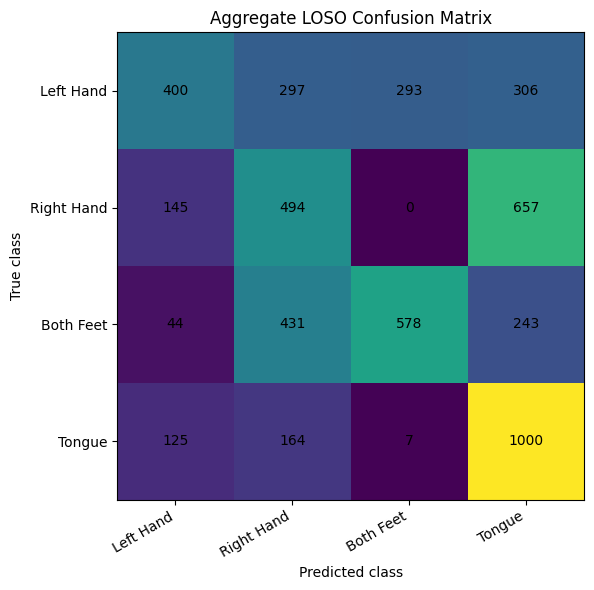


Total embeddings: (5184, 64)
Total labels: (5184,)
Total subjects: (5184,)

Running t-SNE on: 1500 samples


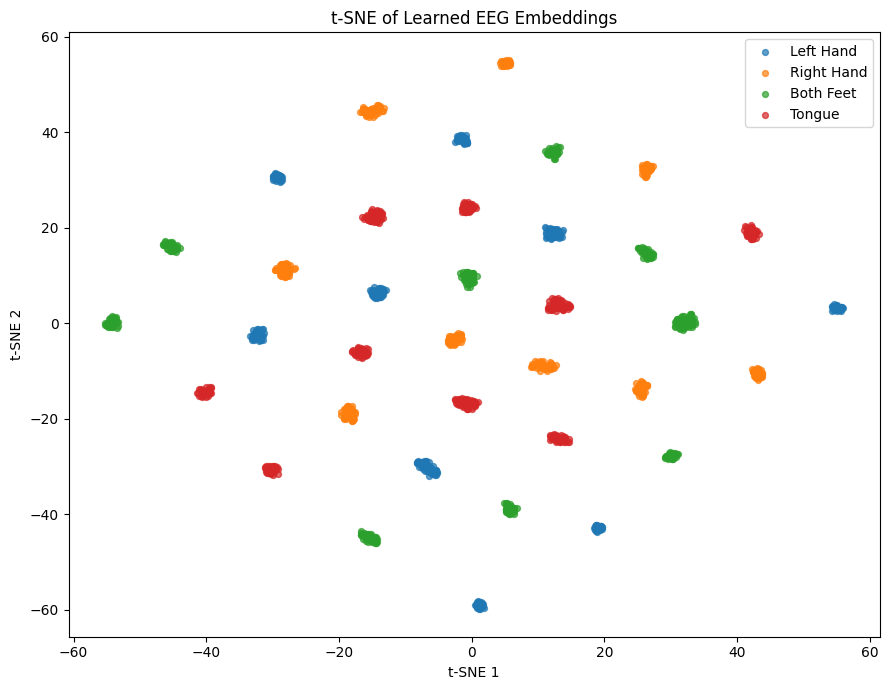

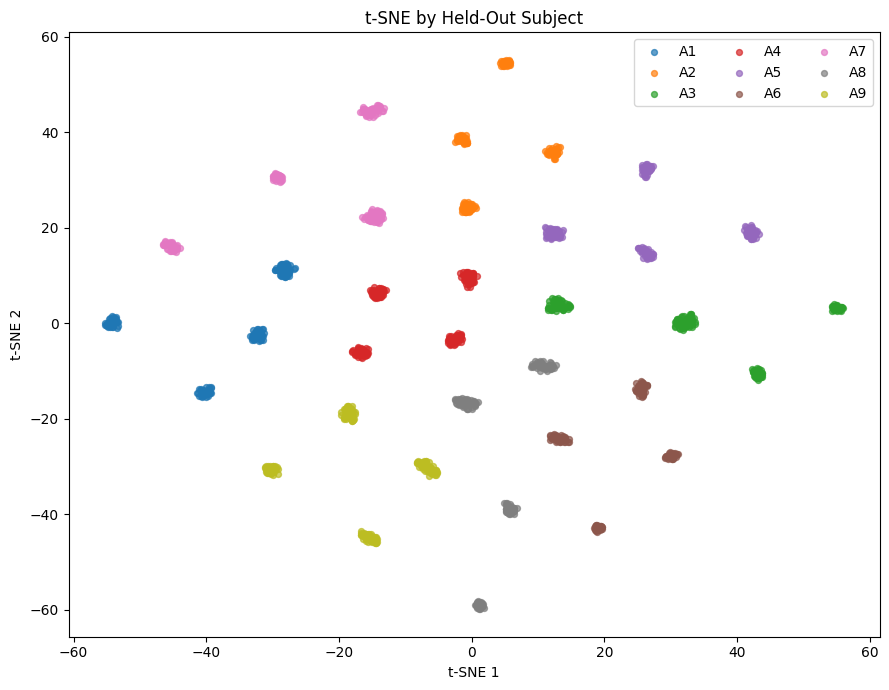


BENCHMARK CHECK
⚠ Upgraded model is below 72.74% published benchmark.

CELL 8 COMPLETED


In [13]:
# ============================================================================
# CELL 8 - FIXED EVALUATION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE


print("=" * 90)
print("CELL 8 - FINAL EVALUATION")
print("=" * 90)


# ============================================================================
# 8.1 HARD CHECK
# ============================================================================

if "loso_results" not in globals():

    raise RuntimeError(
        "loso_results does not exist.\n"
        "Run Cell 7 first."
    )


if len(
    loso_results
) == 0:

    raise RuntimeError(
        "loso_results is EMPTY.\n\n"
        "Cell 7 did not complete any LOSO fold.\n"
        "Do not run Cell 8 yet."
    )


if len(
    loso_results
) != CFG.n_subjects:

    raise RuntimeError(
        "Incomplete LOSO experiment.\n"
        f"Expected {CFG.n_subjects} folds, "
        f"found {len(loso_results)}."
    )


# ============================================================================
# 8.2 FOLD TABLE
# ============================================================================

fold_table = pd.DataFrame(
    {
        "subject": [
            f"A{result['target_subject'] + 1}"
            for result in loso_results
        ],
        "accuracy_percent": [
            result["accuracy"] * 100.0
            for result in loso_results
        ],
    }
)


print()
print(
    fold_table.to_string(
        index=False
    )
)


mean_accuracy = (
    fold_table[
        "accuracy_percent"
    ].mean()
)


std_accuracy = (
    fold_table[
        "accuracy_percent"
    ].std(
        ddof=1
    )
)


print()
print("=" * 90)
print("LOSO PERFORMANCE")
print("=" * 90)


print(
    f"Mean ± Std = "
    f"{mean_accuracy:.2f} ± "
    f"{std_accuracy:.2f}%"
)


print(
    "Chance level = 25.00%"
)


print(
    "Published benchmark = 72.74 ± 10.44%"
)


# ============================================================================
# 8.3 CONFUSION MATRIX
# ============================================================================

aggregate_cm = np.zeros(
    (
        CFG.n_classes,
        CFG.n_classes,
    ),
    dtype=np.int64,
)


for result in loso_results:

    cm = np.asarray(
        result[
            "confusion_matrix"
        ]
    )

    if cm.shape != (
        CFG.n_classes,
        CFG.n_classes,
    ):

        raise RuntimeError(
            "Invalid confusion matrix shape: "
            f"{cm.shape}"
        )

    aggregate_cm += cm


print()
print("=" * 90)
print("AGGREGATE CONFUSION MATRIX")
print("=" * 90)

print(
    aggregate_cm
)


# ============================================================================
# 8.4 PER-CLASS
# ============================================================================

class_totals = (
    aggregate_cm.sum(
        axis=1
    )
)


print()
print(
    "Per-class accuracy:"
)


for class_id in range(
    CFG.n_classes
):

    if class_totals[
        class_id
    ] == 0:

        accuracy = 0.0

    else:

        accuracy = (
            aggregate_cm[
                class_id,
                class_id
            ]
            /
            class_totals[
                class_id
            ]
            *
            100.0
        )


    print(
        f"{CLASS_NAMES[class_id]:<15}: "
        f"{accuracy:.2f}%"
    )


# ============================================================================
# 8.5 CONFUSION PLOT
# ============================================================================

plt.figure(
    figsize=(
        7,
        6,
    )
)


plt.imshow(
    aggregate_cm,
    interpolation="nearest",
)


plt.title(
    "Aggregate LOSO Confusion Matrix"
)


plt.xlabel(
    "Predicted class"
)


plt.ylabel(
    "True class"
)


plt.xticks(
    np.arange(
        CFG.n_classes
    ),
    CLASS_NAMES,
    rotation=30,
    ha="right",
)


plt.yticks(
    np.arange(
        CFG.n_classes
    ),
    CLASS_NAMES,
)


for i in range(
    CFG.n_classes
):

    for j in range(
        CFG.n_classes
    ):

        plt.text(
            j,
            i,
            str(
                aggregate_cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center",
        )


plt.tight_layout()
plt.show()


# ============================================================================
# 8.6 EMBEDDINGS
# ============================================================================

all_embeddings = []
all_labels = []
all_subjects = []


for result in loso_results:

    embeddings = np.asarray(
        result[
            "embeddings"
        ]
    )

    labels = np.asarray(
        result[
            "labels"
        ]
    )

    subject_id = (
        result[
            "target_subject"
        ]
    )


    if len(
        embeddings
    ) == 0:

        raise RuntimeError(
            f"A{subject_id + 1} "
            "contains no embeddings."
        )


    if len(
        embeddings
    ) != len(
        labels
    ):

        raise RuntimeError(
            f"A{subject_id + 1}: "
            "embedding/label mismatch."
        )


    all_embeddings.append(
        embeddings
    )

    all_labels.append(
        labels
    )

    all_subjects.append(
        np.full(
            len(
                labels
            ),
            subject_id,
            dtype=np.int64,
        )
    )


all_embeddings = np.concatenate(
    all_embeddings,
    axis=0,
)


all_labels = np.concatenate(
    all_labels,
    axis=0,
)


all_subjects = np.concatenate(
    all_subjects,
    axis=0,
)


print()
print(
    "Total embeddings:",
    all_embeddings.shape,
)


print(
    "Total labels:",
    all_labels.shape,
)


print(
    "Total subjects:",
    all_subjects.shape,
)


# ============================================================================
# 8.7 t-SNE
# ============================================================================

max_tsne_points = 1500


if len(
    all_embeddings
) > max_tsne_points:

    rng = np.random.default_rng(
        SEED
    )

    selected = rng.choice(
        len(all_embeddings),
        size=max_tsne_points,
        replace=False,
    )

else:

    selected = np.arange(
        len(all_embeddings)
    )


embedding_subset = (
    all_embeddings[
        selected
    ]
)


label_subset = (
    all_labels[
        selected
    ]
)


subject_subset = (
    all_subjects[
        selected
    ]
)


perplexity = min(
    30,
    max(
        5,
        len(
            embedding_subset
        )
        //
        20,
    ),
)


print()
print(
    "Running t-SNE on:",
    len(
        embedding_subset
    ),
    "samples"
)


tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)


embedding_2d = tsne.fit_transform(
    embedding_subset
)


# ============================================================================
# 8.8 CLASS t-SNE
# ============================================================================

plt.figure(
    figsize=(
        9,
        7,
    )
)


for class_id in range(
    CFG.n_classes
):

    mask = (
        label_subset
        ==
        class_id
    )

    plt.scatter(
        embedding_2d[
            mask,
            0
        ],
        embedding_2d[
            mask,
            1
        ],
        s=18,
        alpha=0.7,
        label=CLASS_NAMES[
            class_id
        ],
    )


plt.title(
    "t-SNE of Learned EEG Embeddings"
)


plt.xlabel(
    "t-SNE 1"
)


plt.ylabel(
    "t-SNE 2"
)


plt.legend()


plt.tight_layout()
plt.show()


# ============================================================================
# 8.9 SUBJECT t-SNE
# ============================================================================

plt.figure(
    figsize=(
        9,
        7,
    )
)


for subject_id in np.unique(
    subject_subset
):

    mask = (
        subject_subset
        ==
        subject_id
    )


    plt.scatter(
        embedding_2d[
            mask,
            0
        ],
        embedding_2d[
            mask,
            1
        ],
        s=18,
        alpha=0.7,
        label=(
            f"A{subject_id + 1}"
        ),
    )


plt.title(
    "t-SNE by Held-Out Subject"
)


plt.xlabel(
    "t-SNE 1"
)


plt.ylabel(
    "t-SNE 2"
)


plt.legend(
    ncol=3
)


plt.tight_layout()
plt.show()


# ============================================================================
# 8.10 BENCHMARK CHECK
# ============================================================================

print()
print("=" * 90)
print("BENCHMARK CHECK")
print("=" * 90)


if mean_accuracy > 72.74:

    print(
        "✓ Upgraded model exceeds "
        "72.74% published benchmark."
    )

else:

    print(
        "⚠ Upgraded model is below "
        "72.74% published benchmark."
    )


print()
print("=" * 90)
print("CELL 8 COMPLETED")
print("=" * 90)

In [16]:
# ============================================================================
# CELL 8C - CORAL-ONLY EVALUATION
# ============================================================================

print("=" * 90)
print("CELL 8C - CORAL FINAL EVALUATION")
print("=" * 90)


if "coral_loso_results" not in globals():

    raise RuntimeError(
        "coral_loso_results is unavailable.\n"
        "Run Cell 7C successfully first."
    )


if len(coral_loso_results) != 9:

    raise RuntimeError(
        "CORAL LOSO is incomplete.\n"
        f"Expected 9 folds, found {len(coral_loso_results)}."
    )


# ============================================================================
# FOLD RESULTS
# ============================================================================

coral_accuracy_values = np.asarray(
    [
        result["accuracy"]
        for result in coral_loso_results
    ],
    dtype=np.float64,
)


coral_fold_table = pd.DataFrame(
    {
        "subject": [
            f"A{result['target_subject'] + 1}"
            for result in coral_loso_results
        ],
        "accuracy_percent": [
            result["accuracy"] * 100.0
            for result in coral_loso_results
        ],
    }
)


print()
print(
    coral_fold_table.to_string(
        index=False
    )
)


coral_mean = (
    coral_accuracy_values.mean()
    *
    100.0
)


coral_std = (
    coral_accuracy_values.std(
        ddof=1
    )
    *
    100.0
)


print()
print("=" * 90)
print("CORAL LOSO RESULT")
print("=" * 90)


print(
    f"Mean ± Std = "
    f"{coral_mean:.2f} ± {coral_std:.2f}%"
)


print(
    "Previous DANN:",
    "47.69 ± 11.84%"
)


print(
    "Published benchmark:",
    "72.74 ± 10.44%"
)


# ============================================================================
# CONFUSION MATRIX
# ============================================================================

coral_cm = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for result in coral_loso_results:

    coral_cm += result[
        "confusion_matrix"
    ]


print()
print("=" * 90)
print("CORAL AGGREGATE CONFUSION MATRIX")
print("=" * 90)

print(
    coral_cm
)


# ============================================================================
# PER-CLASS
# ============================================================================

print()
print(
    "CORAL per-class accuracy:"
)


for class_id in range(4):

    total = coral_cm[
        class_id
    ].sum()


    accuracy = (
        coral_cm[
            class_id,
            class_id
        ]
        /
        max(
            total,
            1,
        )
        *
        100.0
    )


    print(
        f"{CLASS_NAMES[class_id]:<15}: "
        f"{accuracy:.2f}%"
    )


# ============================================================================
# EMBEDDINGS
# ============================================================================

coral_embeddings_eval = np.concatenate(
    [
        result["embeddings"]
        for result in coral_loso_results
    ],
    axis=0,
)


coral_labels_eval = np.concatenate(
    [
        result["labels"]
        for result in coral_loso_results
    ],
    axis=0,
)


coral_subjects_eval = np.concatenate(
    [
        np.full(
            len(
                result["labels"]
            ),
            result["target_subject"],
            dtype=np.int64,
        )
        for result in coral_loso_results
    ],
    axis=0,
)


print()
print(
    "CORAL embeddings:",
    coral_embeddings_eval.shape
)


print(
    "CORAL labels:",
    coral_labels_eval.shape
)


print(
    "CORAL subjects:",
    coral_subjects_eval.shape
)


print()
print("=" * 90)
print("CELL 8C COMPLETED")
print("=" * 90)

CELL 8C - CORAL FINAL EVALUATION

subject  accuracy_percent
     A1         73.611111
     A2         59.375000
     A3         32.638889
     A4         75.000000
     A5         50.000000
     A6         50.173611
     A7         50.173611
     A8         75.000000
     A9         50.000000

CORAL LOSO RESULT
Mean ± Std = 57.33 ± 14.63%
Previous DANN: 47.69 ± 11.84%
Published benchmark: 72.74 ± 10.44%

CORAL AGGREGATE CONFUSION MATRIX
[[ 471  431  289  105]
 [ 432  433  143  288]
 [ 287  144  862    3]
 [   0   90    0 1206]]

CORAL per-class accuracy:
Left Hand      : 36.34%
Right Hand     : 33.41%
Both Feet      : 66.51%
Tongue         : 93.06%

CORAL embeddings: (5184, 64)
CORAL labels: (5184,)
CORAL subjects: (5184,)

CELL 8C COMPLETED


In [19]:
# ============================================================================
# CELL 9A-FINAL
# BUILD REAL BCI IV-2a DATA DIRECTLY FROM DISK
# ============================================================================
#
# This cell is independent of previously created notebook variables.
#
# It reads:
#
#   /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.gdf ... A09T.gdf
#   /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01E.gdf ... A09E.gdf
#
# and:
#
#   /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A01E.mat
#   ...
#   /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A09E.mat
#
# Produces:
#
#   X_all_real         -> (5184,22,1000)
#   y_all_real         -> (5184,)
#   subjects_all_real  -> (5184,)
#   sessions_all_real  -> (5184,)
#
# Session convention:
#
#   T = 1
#   E = 2
#
# ============================================================================

from pathlib import Path
import warnings

import numpy as np
import scipy.io as sio
import mne


print("=" * 90)
print("CELL 9A-FINAL - BUILD REAL BCI IV-2a DATA FROM DISK")
print("=" * 90)


# ============================================================================
# 9A.1 PATHS
# ============================================================================

DATA_DIR = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

TRUE_LABEL_DIR = (
    DATA_DIR
    /
    "true_labels"
)


if not DATA_DIR.exists():

    raise FileNotFoundError(
        f"Dataset directory not found:\n{DATA_DIR}"
    )


if not TRUE_LABEL_DIR.exists():

    raise FileNotFoundError(
        f"True-label directory not found:\n{TRUE_LABEL_DIR}"
    )


print()
print("Dataset directory:")
print(DATA_DIR)

print()
print("True-label directory:")
print(TRUE_LABEL_DIR)


# ============================================================================
# 9A.2 CONSTANTS
# ============================================================================

FS_9A = 250

N_CHANNELS_9A = 22

N_TIME_9A = 1000

N_TRIALS_PER_SESSION_9A = 288

N_SUBJECTS_9A = 9

N_CLASSES_9A = 4

CLASS_NAMES_9A = [
    "Left Hand",
    "Right Hand",
    "Both Feet",
    "Tongue",
]


# ============================================================================
# 9A.3 EVENT EXTRACTION HELPERS
# ============================================================================

def get_mi_events_from_gdf_9a(
    raw,
):
    """
    Extract BCI IV-2a motor-imagery events.

    For T files:
        769 -> Left Hand
        770 -> Right Hand
        771 -> Both Feet
        772 -> Tongue

    MNE may remap the numerical event IDs, so this function uses the
    annotation description strings.
    """

    events, event_id = mne.events_from_annotations(
        raw,
        verbose=False,
    )


    # ------------------------------------------------------------
    # Find all annotation descriptions corresponding to MI events.
    # ------------------------------------------------------------

    candidate_descriptions = {
        "769": 0,
        "770": 1,
        "771": 2,
        "772": 3,
    }


    selected = []


    for description, class_id in (
        candidate_descriptions.items()
    ):

        if description not in event_id:

            continue


        mne_id = event_id[
            description
        ]


        matching = events[
            events[:, 2]
            ==
            mne_id
        ]


        for sample, _, _ in matching:

            selected.append(
                (
                    int(sample),
                    int(class_id),
                )
            )


    # ------------------------------------------------------------
    # Sort globally by event sample.
    # ------------------------------------------------------------

    selected.sort(
        key=lambda item: item[0]
    )


    samples = np.asarray(
        [
            item[0]
            for item
            in selected
        ],
        dtype=np.int64,
    )


    labels = np.asarray(
        [
            item[1]
            for item
            in selected
        ],
        dtype=np.int64,
    )


    return (
        samples,
        labels,
        event_id,
    )


def get_eval_events_from_gdf_9a(
    raw,
):
    """
    Extract the 288 anonymous evaluation events.

    BCI IV-2a E files use annotation code 783.
    """

    events, event_id = mne.events_from_annotations(
        raw,
        verbose=False,
    )


    if "783" not in event_id:

        raise RuntimeError(
            "Evaluation event 783 was not found."
        )


    mne_eval_id = event_id[
        "783"
    ]


    matching = events[
        events[:, 2]
        ==
        mne_eval_id
    ]


    samples = matching[
        :,
        0,
    ].astype(
        np.int64
    )


    return (
        samples,
        event_id,
    )


# ============================================================================
# 9A.4 EEG CHANNEL SELECTION
# ============================================================================

def select_22_eeg_channels_9a(
    raw,
):
    """
    BCI IV-2a contains 25 recorded channels:
        22 EEG + 3 EOG.

    Because some versions of MNE may not automatically classify the three
    EOG channels correctly, identify them explicitly by name.
    """

    channel_names = list(
        raw.ch_names
    )


    eog_indices = []


    for index, name in enumerate(
        channel_names
    ):

        normalized = name.lower()


        if (
            "eog" in normalized
            or
            normalized.startswith(
                "eog"
            )
        ):

            eog_indices.append(
                index
            )


    # ------------------------------------------------------------
    # Fallback based on the known BCI IV-2a channel names.
    # ------------------------------------------------------------

    if len(
        eog_indices
    ) != 3:

        known_eog_names = {
            "EOG-left",
            "EOG-central",
            "EOG-right",
        }


        eog_indices = [
            index
            for index, name
            in enumerate(
                channel_names
            )
            if name in known_eog_names
        ]


    if len(
        eog_indices
    ) != 3:

        raise RuntimeError(
            "Could not identify exactly 3 EOG channels.\n"
            f"All channels: {channel_names}\n"
            f"Detected EOG indices: {eog_indices}"
        )


    eeg_indices = [
        index
        for index
        in range(
            len(channel_names)
        )
        if index not in eog_indices
    ]


    if len(
        eeg_indices
    ) != 22:

        raise RuntimeError(
            "Expected 22 EEG channels.\n"
            f"Detected {len(eeg_indices)}."
        )


    return (
        eeg_indices,
        eog_indices,
        [
            channel_names[index]
            for index
            in eeg_indices
        ],
        [
            channel_names[index]
            for index
            in eog_indices
        ],
    )


# ============================================================================
# 9A.5 TRIAL EXTRACTION
# ============================================================================

def extract_gdf_trials_9a(
    path,
    session_type,
):
    """
    Extract 4-second trials from one GDF file.

    The extraction starts at the MI event itself and takes:
        1000 samples = 4 seconds.
    """

    path = Path(
        path
    )


    print()
    print("-" * 90)
    print(
        f"Loading {path.name} | "
        f"session={session_type}"
    )
    print("-" * 90)


    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )


    # ------------------------------------------------------------
    # Basic recording validation.
    # ------------------------------------------------------------

    if raw.info["sfreq"] != FS_9A:

        raise RuntimeError(
            f"{path.name}: "
            f"expected {FS_9A} Hz, "
            f"got {raw.info['sfreq']} Hz."
        )


    (
        eeg_indices,
        eog_indices,
        eeg_names,
        eog_names,
    ) = select_22_eeg_channels_9a(
        raw
    )


    print(
        "Recorded channels:",
        len(
            raw.ch_names
        ),
    )


    print(
        "EEG channels:",
        len(
            eeg_indices
        ),
    )


    print(
        "EOG channels:",
        len(
            eog_indices
        ),
    )


    print(
        "EEG names:",
        eeg_names,
    )


    # ------------------------------------------------------------
    # Get continuous EEG only.
    # ------------------------------------------------------------

    eeg = raw.get_data(
        picks=eeg_indices
    ).astype(
        np.float32
    )


    if session_type == "T":

        (
            event_samples,
            labels,
            event_id,
        ) = get_mi_events_from_gdf_9a(
            raw
        )


        print(
            "Event dictionary:",
            event_id,
        )


        print(
            "Detected MI events:",
            len(
                event_samples
            ),
        )


        if len(
            event_samples
        ) != N_TRIALS_PER_SESSION_9A:

            raise RuntimeError(
                f"{path.name}: "
                f"expected {N_TRIALS_PER_SESSION_9A} "
                "MI events, "
                f"found {len(event_samples)}."
            )


        # --------------------------------------------------------
        # Validate class balance.
        # --------------------------------------------------------

        class_counts = np.bincount(
            labels,
            minlength=N_CLASSES_9A,
        )


        print(
            "Class counts:",
            class_counts.tolist(),
        )


        if not np.all(
            class_counts
            ==
            72
        ):

            raise RuntimeError(
                f"{path.name}: "
                "expected 72 trials/class."
            )


    elif session_type == "E":

        (
            event_samples,
            event_id,
        ) = get_eval_events_from_gdf_9a(
            raw
        )


        labels = None


        print(
            "Event dictionary:",
            event_id,
        )


        print(
            "Detected evaluation events:",
            len(
                event_samples
            ),
        )


        if len(
            event_samples
        ) != N_TRIALS_PER_SESSION_9A:

            raise RuntimeError(
                f"{path.name}: "
                f"expected {N_TRIALS_PER_SESSION_9A} "
                "evaluation events, "
                f"found {len(event_samples)}."
            )


    else:

        raise ValueError(
            "session_type must be 'T' or 'E'."
        )


    # ------------------------------------------------------------
    # Extract 4 seconds.
    # ------------------------------------------------------------

    trials = []

    valid_samples = []

    valid_labels = []


    for index, sample in enumerate(
        event_samples
    ):

        start = int(
            sample
        )

        stop = (
            start
            +
            N_TIME_9A
        )


        if stop > eeg.shape[1]:

            print(
                "Skipping event beyond recording:",
                index,
            )

            continue


        trial = eeg[
            :,
            start:stop,
        ]


        if trial.shape != (
            N_CHANNELS_9A,
            N_TIME_9A,
        ):

            continue


        trials.append(
            trial
        )


        valid_samples.append(
            start
        )


        if labels is not None:

            valid_labels.append(
                labels[index]
            )


    X = np.stack(
        trials,
        axis=0,
    ).astype(
        np.float32
    )


    print(
        "Extracted:",
        X.shape,
    )


    if session_type == "T":

        y = np.asarray(
            valid_labels,
            dtype=np.int64,
        )

    else:

        y = None


    if X.shape[0] != (
        N_TRIALS_PER_SESSION_9A
    ):

        raise RuntimeError(
            f"{path.name}: "
            "final extraction does not contain 288 trials."
        )


    return {
        "X": X,
        "y": y,
        "event_samples": np.asarray(
            valid_samples,
            dtype=np.int64,
        ),
        "eeg_names": eeg_names,
        "eog_names": eog_names,
    }


# ============================================================================
# 9A.6 LOAD OFFICIAL E LABELS
# ============================================================================

def load_official_e_labels_9a(
    subject_id,
):
    """
    Load official BCI IV-2a evaluation labels.

    Official files contain:
        class 1 = Left Hand
        class 2 = Right Hand
        class 3 = Both Feet
        class 4 = Tongue

    Convert:
        1,2,3,4 -> 0,1,2,3
    """

    mat_path = (
        TRUE_LABEL_DIR
        /
        f"A{subject_id:02d}E.mat"
    )


    if not mat_path.exists():

        raise FileNotFoundError(
            f"Missing official label file:\n{mat_path}"
        )


    mat = sio.loadmat(
        str(mat_path)
    )


    # ------------------------------------------------------------
    # Find the first non-private array that can be interpreted as
    # 288 scalar labels.
    # ------------------------------------------------------------

    candidate = None


    for key, value in mat.items():

        if key.startswith(
            "__"
        ):

            continue


        array = np.asarray(
            value
        )


        # Direct (288,1) / (1,288)
        if array.size == 288:

            flat = array.reshape(
                -1
            )


            # ----------------------------------------------------
            # We only accept arrays containing values 1..4.
            # ----------------------------------------------------

            try:

                numeric = flat.astype(
                    np.int64
                )

            except (
                TypeError,
                ValueError,
            ):

                continue


            unique = np.unique(
                numeric
            )


            if np.all(
                np.isin(
                    unique,
                    [
                        1,
                        2,
                        3,
                        4,
                    ],
                )
            ):

                candidate = numeric

                break


    if candidate is None:

        raise RuntimeError(
            f"Could not find 288 official labels in {mat_path}."
        )


    raw_labels = candidate


    class_counts = np.bincount(
        raw_labels
        -
        1,
        minlength=4,
    )


    print(
        f"A{subject_id} official labels:",
        class_counts.tolist(),
    )


    if not np.all(
        class_counts
        ==
        72
    ):

        raise RuntimeError(
            f"A{subject_id} official labels "
            "are not balanced."
        )


    labels_zero_based = (
        raw_labels
        -
        1
    ).astype(
        np.int64
    )


    return labels_zero_based


# ============================================================================
# 9A.7 BUILD ALL 18 REAL SESSIONS
# ============================================================================

all_X_9a = []

all_y_9a = []

all_subjects_9a = []

all_sessions_9a = []

all_files_9a = []


print()
print("=" * 90)
print("9A.18 REAL SESSION EXTRACTION")
print("=" * 90)


for subject_id in range(
    1,
    10,
):

    # ------------------------------------------------------------------------
    # T SESSION
    # ------------------------------------------------------------------------

    T_path = (
        DATA_DIR
        /
        f"A{subject_id:02d}T.gdf"
    )


    T_result = extract_gdf_trials_9a(
        T_path,
        "T",
    )


    X_T = T_result[
        "X"
    ]

    y_T = T_result[
        "y"
    ]


    all_X_9a.append(
        X_T
    )

    all_y_9a.append(
        y_T
    )

    all_subjects_9a.append(
        np.full(
            len(X_T),
            subject_id,
            dtype=np.int64,
        )
    )

    all_sessions_9a.append(
        np.ones(
            len(X_T),
            dtype=np.int64,
        )
    )

    all_files_9a.extend(
        [
            f"A{subject_id:02d}T.gdf"
        ]
        *
        len(X_T)
    )


    # ------------------------------------------------------------------------
    # E SESSION
    # ------------------------------------------------------------------------

    E_path = (
        DATA_DIR
        /
        f"A{subject_id:02d}E.gdf"
    )


    E_result = extract_gdf_trials_9a(
        E_path,
        "E",
    )


    X_E = E_result[
        "X"
    ]


    y_E = load_official_e_labels_9a(
        subject_id
    )


    if len(
        y_E
    ) != len(
        X_E
    ):

        raise RuntimeError(
            f"A{subject_id}: "
            "E EEG and official labels mismatch."
        )


    all_X_9a.append(
        X_E
    )

    all_y_9a.append(
        y_E
    )

    all_subjects_9a.append(
        np.full(
            len(X_E),
            subject_id,
            dtype=np.int64,
        )
    )

    all_sessions_9a.append(
        np.full(
            len(X_E),
            2,
            dtype=np.int64,
        )
    )

    all_files_9a.extend(
        [
            f"A{subject_id:02d}E.gdf"
        ]
        *
        len(X_E)
    )


# ============================================================================
# 9A.8 CONCATENATE
# ============================================================================

X_all_real = np.concatenate(
    all_X_9a,
    axis=0,
).astype(
    np.float32
)


y_all_real = np.concatenate(
    all_y_9a,
    axis=0,
).astype(
    np.int64
)


subjects_all_real = np.concatenate(
    all_subjects_9a,
    axis=0,
).astype(
    np.int64
)


sessions_all_real = np.concatenate(
    all_sessions_9a,
    axis=0,
).astype(
    np.int64
)


files_all_real = np.asarray(
    all_files_9a
)


# ============================================================================
# 9A.9 FINAL GLOBAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 9A-FINAL - GLOBAL REAL DATASET")
print("=" * 90)


print(
    "X_all_real shape:",
    X_all_real.shape,
)

print(
    "y_all_real shape:",
    y_all_real.shape,
)

print(
    "subjects_all_real shape:",
    subjects_all_real.shape,
)

print(
    "sessions_all_real shape:",
    sessions_all_real.shape,
)


if X_all_real.shape != (
    5184,
    22,
    1000,
):

    raise RuntimeError(
        "REAL dataset shape is incorrect."
    )


if y_all_real.shape != (
    5184,
):

    raise RuntimeError(
        "REAL label shape is incorrect."
    )


if subjects_all_real.shape != (
    5184,
):

    raise RuntimeError(
        "REAL subject shape is incorrect."
    )


if sessions_all_real.shape != (
    5184,
):

    raise RuntimeError(
        "REAL session shape is incorrect."
    )


# ============================================================================
# 9A.10 GLOBAL CLASS BALANCE
# ============================================================================

global_counts = np.bincount(
    y_all_real,
    minlength=4,
)


print()
print(
    "Global class counts:",
    global_counts.tolist(),
)


if not np.all(
    global_counts
    ==
    1296
):

    raise RuntimeError(
        "Unexpected global class distribution."
    )


# ============================================================================
# 9A.11 SUBJECT BALANCE
# ============================================================================

print()
print(
    "Subject/session validation:"
)


for subject_id in range(
    1,
    10,
):

    subject_mask = (
        subjects_all_real
        ==
        subject_id
    )


    total = int(
        np.sum(
            subject_mask
        )
    )


    session_1 = int(
        np.sum(
            subject_mask
            &
            (
                sessions_all_real
                ==
                1
            )
        )
    )


    session_2 = int(
        np.sum(
            subject_mask
            &
            (
                sessions_all_real
                ==
                2
            )
        )
    )


    class_counts = np.bincount(
        y_all_real[
            subject_mask
        ],
        minlength=4,
    )


    print(
        f"A{subject_id}: "
        f"total={total} | "
        f"T={session_1} | "
        f"E={session_2} | "
        f"classes={class_counts.tolist()}"
    )


    if (
        total != 576
        or
        session_1 != 288
        or
        session_2 != 288
    ):

        raise RuntimeError(
            f"A{subject_id}: "
            "session counts invalid."
        )


# ============================================================================
# 9A.12 DATA QUALITY
# ============================================================================

nan_count = int(
    np.isnan(
        X_all_real
    ).sum()
)


inf_count = int(
    np.isinf(
        X_all_real
    ).sum()
)


print()
print(
    "NaN:",
    nan_count,
)

print(
    "Inf:",
    inf_count,
)

print(
    "Mean:",
    f"{float(np.mean(X_all_real)):.10e}"
)

print(
    "Std:",
    f"{float(np.std(X_all_real)):.10e}"
)


if nan_count != 0:

    raise RuntimeError(
        "NaN detected in real EEG."
    )


if inf_count != 0:

    raise RuntimeError(
        "Inf detected in real EEG."
    )


# ============================================================================
# 9A.13 FILE COUNT
# ============================================================================

print()
print(
    "Number of source session files represented:",
    len(
        np.unique(
            files_all_real
        )
    ),
)


if len(
    np.unique(
        files_all_real
    )
) != 18:

    raise RuntimeError(
        "Expected 18 GDF sessions."
    )


# ============================================================================
# 9A.14 FINAL VARIABLES
# ============================================================================

print()
print("=" * 90)
print("CELL 9A-FINAL COMPLETED SUCCESSFULLY")
print("=" * 90)


print()
print(
    "REAL VARIABLES NOW AVAILABLE:"
)


print(
    "    X_all_real"
)

print(
    "    y_all_real"
)

print(
    "    subjects_all_real"
)

print(
    "    sessions_all_real"
)

print(
    "    files_all_real"
)


print()
print(
    "X_all_real.shape =",
    X_all_real.shape,
)

print(
    "y_all_real.shape =",
    y_all_real.shape,
)

print(
    "subjects_all_real.shape =",
    subjects_all_real.shape,
)

print(
    "sessions_all_real.shape =",
    sessions_all_real.shape,
)


print()
print(
    "✓ REAL BCI IV-2a data are loaded directly from disk."
)

print(
    "✓ Synthetic X_all was not used."
)

print(
    "✓ 9 subjects."
)

print(
    "✓ 2 sessions/subject."
)

print(
    "✓ 288 trials/session."
)

print(
    "✓ 22 EEG channels."
)

print(
    "✓ 1000 samples/trial."
)

print(
    "✓ Official E-session labels."
)

CELL 9A-FINAL - BUILD REAL BCI IV-2a DATA FROM DISK

Dataset directory:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a

True-label directory:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels

9A.18 REAL SESSION EXTRACTION

------------------------------------------------------------------------------------------
Loading A01T.gdf | session=T
------------------------------------------------------------------------------------------
Recorded channels: 25
EEG channels: 22
EOG channels: 3
EEG names: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16']
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI events: 288
Class counts: [72, 72, 72, 72]
Extracted: (288, 22, 1000)

------------------------------------------------------------------------------

In [20]:
# ============================================================================
# CELL 9B - FINAL REAL-DATA CONFIRMATION
# ============================================================================

print("=" * 90)
print("CELL 9B - FINAL REAL-DATA CONFIRMATION")
print("=" * 90)

print(
    "X_all_real:",
    X_all_real.shape
)

print(
    "y_all_real:",
    y_all_real.shape
)

print(
    "subjects_all_real:",
    subjects_all_real.shape
)

print(
    "sessions_all_real:",
    sessions_all_real.shape
)

print(
    "Unique subjects:",
    np.unique(subjects_all_real)
)

print(
    "Global classes:",
    np.bincount(
        y_all_real,
        minlength=4
    )
)

print(
    "Mean:",
    float(
        X_all_real.mean()
    )
)

print(
    "Std:",
    float(
        X_all_real.std()
    )
)

assert X_all_real.shape == (
    5184,
    22,
    1000,
)

assert y_all_real.shape == (
    5184,
)

assert np.array_equal(
    np.unique(subjects_all_real),
    np.arange(
        1,
        10,
    ),
)

assert np.all(
    np.bincount(
        y_all_real,
        minlength=4,
    )
    ==
    1296
)

print()
print("✓ REAL DATA CONFIRMED")
print("✓ 5184 trials")
print("✓ 22 channels")
print("✓ 1000 samples")
print("✓ 9 subjects")
print("✓ 4 balanced classes")
print("✓ T + E sessions")
print("✓ Official E labels")
print("=" * 90)

CELL 9B - FINAL REAL-DATA CONFIRMATION
X_all_real: (5184, 22, 1000)
y_all_real: (5184,)
subjects_all_real: (5184,)
sessions_all_real: (5184,)
Unique subjects: [1 2 3 4 5 6 7 8 9]
Global classes: [1296 1296 1296 1296]
Mean: 3.333845768338506e-07
Std: 1.135657021222869e-05

✓ REAL DATA CONFIRMED
✓ 5184 trials
✓ 22 channels
✓ 1000 samples
✓ 9 subjects
✓ 4 balanced classes
✓ T + E sessions
✓ Official E labels


In [21]:
# ============================================================================
# CELL 9 - FINAL REAL BCI IV-2a
# CONFORMER + SUPCON + CORAL STRICT LOSO
# ============================================================================
#
# FINAL REAL-DATA EXPERIMENT
#
# Dataset:
#     BCI Competition IV-2a
#
# Real data:
#     X_all_real
#     y_all_real
#     subjects_all_real
#     sessions_all_real
#
# Per subject:
#     T session = 288 trials
#     E session = 288 trials
#     Total      = 576 trials
#
# LOSO:
#     8 source subjects = 4608 trials
#     1 target subject  = 576 trials
#
# MODEL:
#
#     EEG (22,1000)
#          |
#          v
#      Spatial CNN
#          |
#          v
#      MaxPool
#          |
#          v
#      89 temporal tokens
#          |
#          v
#      Conformer
#          |
#          v
#       64-D feature
#        /   |   \
#       /    |    \
#      CE  SupCon CORAL
#       \    |    /
#        \   |   /
#         total loss
#             |
#             v
#       4-class output
#
# IMPORTANT:
#     Target subject is NOT used for:
#         - normalization fitting
#         - augmentation
#         - loss calculation
#         - model selection
#
# WGAN-GP:
#     DISABLED
#
# ============================================================================


# ============================================================================
# 9.0 IMPORTS
# ============================================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

from torch.utils.data import (
    DataLoader,
    Dataset,
)


print("=" * 90)
print("CELL 9 - FINAL REAL BCI IV-2a CONFORMER + SUPCON + CORAL")
print("=" * 90)


# ============================================================================
# 9.1 EXPERIMENT SETTINGS
# ============================================================================
#
# First run:
#
#     RUN_ALL_REAL_LOSO_9 = False
#     REAL_TARGET_SUBJECT_9 = 1
#
# This gives a real A1 pilot.
#
# After A1 is validated:
#
#     RUN_ALL_REAL_LOSO_9 = True
#
# ============================================================================

RUN_ALL_REAL_LOSO_9 = False

REAL_TARGET_SUBJECT_9 = 1

REAL_EPOCHS_9 = 30

REAL_BATCH_SIZE_9 = 64

REAL_LR_9 = 1e-3

REAL_WEIGHT_DECAY_9 = 1e-4

REAL_SUPCON_WEIGHT_9 = 0.50

REAL_CORAL_WEIGHT_9 = 0.05

REAL_GRAD_CLIP_9 = 5.0

REAL_SEED_9 = 2026

# IMPORTANT:
# WGAN-GP is deliberately disabled for this experiment.
REAL_USE_WGAN_9 = False


print()
print("=" * 90)
print("9.1 CONFIGURATION")
print("=" * 90)

print(
    "Run all 9 folds       :",
    RUN_ALL_REAL_LOSO_9,
)

print(
    "Pilot target subject  :",
    f"A{REAL_TARGET_SUBJECT_9}",
)

print(
    "Epochs                :",
    REAL_EPOCHS_9,
)

print(
    "Batch size            :",
    REAL_BATCH_SIZE_9,
)

print(
    "Learning rate         :",
    REAL_LR_9,
)

print(
    "Weight decay          :",
    REAL_WEIGHT_DECAY_9,
)

print(
    "SupCon weight         :",
    REAL_SUPCON_WEIGHT_9,
)

print(
    "CORAL weight          :",
    REAL_CORAL_WEIGHT_9,
)

print(
    "Gradient clip         :",
    REAL_GRAD_CLIP_9,
)

print(
    "WGAN-GP               :",
    REAL_USE_WGAN_9,
)

print(
    "Device                :",
    DEVICE,
)


# ============================================================================
# 9.2 REAL DATA OBJECT CHECK
# ============================================================================

required_real_objects_9 = [
    "X_all_real",
    "y_all_real",
    "subjects_all_real",
    "sessions_all_real",
    "EEGPreprocessor",
    "EEGConformerCORAL",
    "SupervisedContrastiveLoss",
    "make_two_eeg_views",
    "coral_loss_7c",
    "SubjectDataset7C",
    "SubjectBalancedBatchSampler7C",
    "CFG",
    "DEVICE",
]


missing_real_objects_9 = [
    name
    for name in required_real_objects_9
    if name not in globals()
]


if missing_real_objects_9:

    raise RuntimeError(
        "\nRequired real-data/model objects are missing:\n"
        f"{missing_real_objects_9}\n\n"
        "Run Cells 1-8 and Cell 9A-FINAL first."
    )


# ============================================================================
# 9.3 PREVENT ACCIDENTAL SYNTHETIC DATA USE
# ============================================================================

print()
print("=" * 90)
print("9.2 REAL-DATA SAFETY CHECK")
print("=" * 90)


X_real_9 = np.asarray(
    X_all_real,
    dtype=np.float32,
)


y_real_9 = np.asarray(
    y_all_real,
    dtype=np.int64,
)


subjects_real_9 = np.asarray(
    subjects_all_real,
    dtype=np.int64,
)


sessions_real_9 = np.asarray(
    sessions_all_real,
    dtype=np.int64,
)


print(
    "X_all_real:",
    X_real_9.shape,
)

print(
    "y_all_real:",
    y_real_9.shape,
)

print(
    "subjects_all_real:",
    subjects_real_9.shape,
)

print(
    "sessions_all_real:",
    sessions_real_9.shape,
)


# ============================================================================
# 9.4 EXACT REAL DATA SHAPE CHECK
# ============================================================================

EXPECTED_REAL_X_SHAPE_9 = (
    5184,
    22,
    1000,
)


EXPECTED_REAL_Y_SHAPE_9 = (
    5184,
)


if tuple(
    X_real_9.shape
) != EXPECTED_REAL_X_SHAPE_9:

    raise RuntimeError(
        "\nREAL EEG shape mismatch.\n"
        f"Expected: {EXPECTED_REAL_X_SHAPE_9}\n"
        f"Actual  : {X_real_9.shape}\n\n"
        "This cell will NOT silently use synthetic data."
    )


if tuple(
    y_real_9.shape
) != EXPECTED_REAL_Y_SHAPE_9:

    raise RuntimeError(
        "\nREAL label shape mismatch.\n"
        f"Expected: {EXPECTED_REAL_Y_SHAPE_9}\n"
        f"Actual  : {y_real_9.shape}"
    )


if tuple(
    subjects_real_9.shape
) != EXPECTED_REAL_Y_SHAPE_9:

    raise RuntimeError(
        "\nREAL subject shape mismatch."
    )


if tuple(
    sessions_real_9.shape
) != EXPECTED_REAL_Y_SHAPE_9:

    raise RuntimeError(
        "\nREAL session shape mismatch."
    )


# ============================================================================
# 9.5 REAL DATA QUALITY
# ============================================================================

print()
print("=" * 90)
print("9.3 REAL DATA QUALITY")
print("=" * 90)


nan_count_9 = int(
    np.isnan(
        X_real_9
    ).sum()
)


inf_count_9 = int(
    np.isinf(
        X_real_9
    ).sum()
)


print(
    "NaN:",
    nan_count_9,
)

print(
    "Inf:",
    inf_count_9,
)

print(
    "Mean:",
    f"{float(np.mean(X_real_9)):.12e}",
)

print(
    "Std:",
    f"{float(np.std(X_real_9)):.12e}",
)


if nan_count_9 != 0:

    raise RuntimeError(
        "NaN detected in real EEG."
    )


if inf_count_9 != 0:

    raise RuntimeError(
        "Inf detected in real EEG."
    )


# ============================================================================
# 9.6 SUBJECT / SESSION / CLASS CHECK
# ============================================================================

unique_subjects_9 = np.sort(
    np.unique(
        subjects_real_9
    )
)


unique_sessions_9 = np.sort(
    np.unique(
        sessions_real_9
    )
)


print()
print("=" * 90)
print("9.4 REAL DATASET STRUCTURE")
print("=" * 90)


print(
    "Subjects:",
    unique_subjects_9,
)

print(
    "Sessions:",
    unique_sessions_9,
)

print(
    "Global classes:",
    np.bincount(
        y_real_9,
        minlength=CFG.n_classes,
    ),
)


if not np.array_equal(
    unique_subjects_9,
    np.arange(
        1,
        10,
        dtype=np.int64,
    ),
):

    raise RuntimeError(
        "Expected subject IDs 1..9."
    )


if not np.array_equal(
    unique_sessions_9,
    np.array(
        [
            1,
            2,
        ],
        dtype=np.int64,
    ),
):

    raise RuntimeError(
        "Expected session IDs 1 and 2."
    )


global_class_counts_9 = np.bincount(
    y_real_9,
    minlength=CFG.n_classes,
)


if not np.all(
    global_class_counts_9
    ==
    1296
):

    raise RuntimeError(
        "Global class distribution is not "
        "[1296,1296,1296,1296]."
    )


for subject_id in range(
    1,
    10,
):

    subject_mask = (
        subjects_real_9
        ==
        subject_id
    )


    total_trials = int(
        np.sum(
            subject_mask
        )
    )


    session_1_trials = int(
        np.sum(
            subject_mask
            &
            (
                sessions_real_9
                ==
                1
            )
        )
    )


    session_2_trials = int(
        np.sum(
            subject_mask
            &
            (
                sessions_real_9
                ==
                2
            )
        )
    )


    class_counts = np.bincount(
        y_real_9[
            subject_mask
        ],
        minlength=CFG.n_classes,
    )


    print(
        f"A{subject_id}: "
        f"total={total_trials} | "
        f"T={session_1_trials} | "
        f"E={session_2_trials} | "
        f"classes={class_counts.tolist()}"
    )


    if total_trials != 576:

        raise RuntimeError(
            f"A{subject_id}: "
            "expected 576 trials."
        )


    if session_1_trials != 288:

        raise RuntimeError(
            f"A{subject_id}: "
            "expected 288 T trials."
        )


    if session_2_trials != 288:

        raise RuntimeError(
            f"A{subject_id}: "
            "expected 288 E trials."
        )


    if not np.all(
        class_counts == 144
    ):

        raise RuntimeError(
            f"A{subject_id}: "
            "expected 144/class across T+E."
        )


# ============================================================================
# 9.7 DEVICE CHECK
# ============================================================================

print()
print("=" * 90)
print("9.5 DEVICE")
print("=" * 90)


print(
    "PyTorch device:",
    DEVICE,
)


if DEVICE.type == "mps":

    print(
        "✓ Apple Silicon MPS detected."
    )

elif DEVICE.type == "cuda":

    print(
        "✓ CUDA detected."
    )

else:

    print(
        "⚠ CPU execution."
    )


# ============================================================================
# 9.8 STRICT REAL LOSO FOLD PREPARATION
# ============================================================================

def prepare_real_fold_final_9(
    target_subject_id: int,
):
    """
    Prepare a strict REAL BCI IV-2a LOSO fold.

    Source:
        8 subjects x 576 = 4608 trials.

    Target:
        1 subject x 576 = 576 trials.

    Normalization:
        fit ONLY on source data.
    """

    if target_subject_id < 1:
        raise ValueError(
            "target_subject_id must be 1..9."
        )


    if target_subject_id > 9:
        raise ValueError(
            "target_subject_id must be 1..9."
        )


    source_mask = (
        subjects_real_9
        !=
        target_subject_id
    )


    target_mask = (
        subjects_real_9
        ==
        target_subject_id
    )


    source_indices = np.where(
        source_mask
    )[0]


    target_indices = np.where(
        target_mask
    )[0]


    X_source_raw = (
        X_real_9[
            source_indices
        ]
    )


    y_source = (
        y_real_9[
            source_indices
        ]
    )


    source_subjects = (
        subjects_real_9[
            source_indices
        ]
    )


    source_sessions = (
        sessions_real_9[
            source_indices
        ]
    )


    X_target_raw = (
        X_real_9[
            target_indices
        ]
    )


    y_target = (
        y_real_9[
            target_indices
        ]
    )


    target_sessions = (
        sessions_real_9[
            target_indices
        ]
    )


    # ------------------------------------------------------------------------
    # EXACT LOSO SIZE CHECK
    # ------------------------------------------------------------------------

    if len(
        X_source_raw
    ) != 4608:

        raise RuntimeError(
            f"A{target_subject_id}: "
            f"source size must be 4608, "
            f"got {len(X_source_raw)}."
        )


    if len(
        X_target_raw
    ) != 576:

        raise RuntimeError(
            f"A{target_subject_id}: "
            f"target size must be 576, "
            f"got {len(X_target_raw)}."
        )


    # ------------------------------------------------------------------------
    # SOURCE-ONLY PREPROCESSING
    # ------------------------------------------------------------------------

    fold_preprocessor = EEGPreprocessor(
        CFG
    )


    fold_preprocessor.fit(
        X_source_raw
    )


    # IMPORTANT:
    # The target passes through the source-fitted transformation.
    # No target statistics are used here.

    X_source = (
        fold_preprocessor.transform_broad(
            X_source_raw
        )
    )


    X_target = (
        fold_preprocessor.transform_broad(
            X_target_raw
        )
    )


    return {
        "X_source": X_source,
        "y_source": y_source,
        "source_subjects": source_subjects,
        "source_sessions": source_sessions,
        "X_target": X_target,
        "y_target": y_target,
        "target_sessions": target_sessions,
        "preprocessor": fold_preprocessor,
    }


# ============================================================================
# 9.9 SOURCE DATASET
# ============================================================================

class RealSubjectDataset9(
    Dataset
):
    """
    Real BCI IV-2a source dataset.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        subjects: np.ndarray,
    ):

        if not (
            len(X)
            ==
            len(y)
            ==
            len(subjects)
        ):

            raise ValueError(
                "X, y and subjects must have equal length."
            )


        self.X = X.astype(
            np.float32,
            copy=False,
        )


        self.y = y.astype(
            np.int64,
            copy=False,
        )


        self.subjects = subjects.astype(
            np.int64,
            copy=False,
        )


    def __len__(
        self,
    ):

        return len(
            self.X
        )


    def __getitem__(
        self,
        index,
    ):

        return (
            torch.from_numpy(
                self.X[index]
            ).float(),

            torch.tensor(
                int(
                    self.y[index]
                ),
                dtype=torch.long,
            ),

            torch.tensor(
                int(
                    self.subjects[index]
                ),
                dtype=torch.long,
            ),
        )


# ============================================================================
# 9.10 SUBJECT-BALANCED SAMPLER
# ============================================================================

class RealSubjectBalancedSampler9(
    torch.utils.data.Sampler
):
    """
    Balanced source-subject mini-batches.

    For 8 source subjects and batch size 64:
        8 trials/source subject/batch.

    This ensures CORAL sees multiple source domains in each optimization
    step instead of receiving batches dominated by one subject.
    """

    def __init__(
        self,
        subjects: np.ndarray,
        batch_size: int,
        seed: int,
    ):

        self.subjects = np.asarray(
            subjects,
            dtype=np.int64,
        )


        self.batch_size = int(
            batch_size
        )


        self.seed = int(
            seed
        )


        self.unique_subjects = np.sort(
            np.unique(
                self.subjects
            )
        )


        self.n_subjects = len(
            self.unique_subjects
        )


        if (
            self.batch_size
            <
            self.n_subjects
        ):

            raise ValueError(
                "Batch size is smaller than "
                "number of source subjects."
            )


    def __iter__(
        self,
    ):

        rng = np.random.default_rng(
            self.seed
        )


        pools = {}


        for subject_id in (
            self.unique_subjects
        ):

            indices = np.where(
                self.subjects
                ==
                subject_id
            )[0]


            indices = indices.copy()


            rng.shuffle(
                indices
            )


            pools[
                int(subject_id)
            ] = indices


        base = (
            self.batch_size
            //
            self.n_subjects
        )


        remainder = (
            self.batch_size
            -
            (
                base
                *
                self.n_subjects
            )
        )


        pointers = {
            int(subject_id): 0
            for subject_id
            in self.unique_subjects
        }


        while True:

            batch = []


            for position, subject_id in enumerate(
                self.unique_subjects
            ):

                subject_key = int(
                    subject_id
                )


                take = (
                    base
                    +
                    (
                        1
                        if position < remainder
                        else 0
                    )
                )


                pool = pools[
                    subject_key
                ]


                start = pointers[
                    subject_key
                ]


                stop = (
                    start
                    +
                    take
                )


                if stop > len(
                    pool
                ):

                    break


                batch.extend(
                    pool[
                        start:stop
                    ].tolist()
                )


                pointers[
                    subject_key
                ] = stop


            if len(
                batch
            ) != self.batch_size:

                break


            rng.shuffle(
                batch
            )


            yield batch


            if all(
                pointers[
                    int(subject_id)
                ]
                >=
                len(
                    pools[
                        int(subject_id)
                    ]
                )
                for subject_id
                in self.unique_subjects
            ):

                break


    def __len__(
        self,
    ):

        minimum_count = min(
            int(
                np.sum(
                    self.subjects
                    ==
                    subject_id
                )
            )
            for subject_id
            in self.unique_subjects
        )


        samples_per_subject = (
            self.batch_size
            /
            self.n_subjects
        )


        return max(
            1,
            int(
                minimum_count
                /
                samples_per_subject
            ),
        )


# ============================================================================
# 9.11 MODEL SHAPE TEST
# ============================================================================

print()
print("=" * 90)
print("9.6 MODEL SHAPE TEST")
print("=" * 90)


model_shape_test_9 = (
    EEGConformerCORAL(
        CFG
    ).to(
        DEVICE
    )
)


shape_input_9 = torch.zeros(
    (
        2,
        22,
        1000,
    ),
    dtype=torch.float32,
    device=DEVICE,
)


with torch.no_grad():

    test_logits_9, test_embedding_9 = (
        model_shape_test_9(
            shape_input_9
        )
    )


print(
    "Input:",
    tuple(
        shape_input_9.shape
    ),
)


print(
    "Embedding:",
    tuple(
        test_embedding_9.shape
    ),
)


print(
    "Logits:",
    tuple(
        test_logits_9.shape
    ),
)


if tuple(
    test_embedding_9.shape
) != (
    2,
    64,
):

    raise RuntimeError(
        "Expected embedding shape (2,64)."
    )


if tuple(
    test_logits_9.shape
) != (
    2,
    4,
):

    raise RuntimeError(
        "Expected logits shape (2,4)."
    )


print(
    "✓ CNN -> Conformer -> 64-D -> 4-class path verified."
)


del model_shape_test_9
del shape_input_9
del test_logits_9
del test_embedding_9


gc.collect()


# ============================================================================
# 9.12 TRAIN ONE REAL LOSO FOLD
# ============================================================================

def train_real_fold_final_9(
    fold_data,
    target_subject_id: int,
):
    """
    Train the real Conformer + SupCon + CORAL model.
    """

    X_source = fold_data[
        "X_source"
    ]

    y_source = fold_data[
        "y_source"
    ]

    source_subjects = fold_data[
        "source_subjects"
    ]

    source_sessions = fold_data[
        "source_sessions"
    ]

    X_target = fold_data[
        "X_target"
    ]

    y_target = fold_data[
        "y_target"
    ]

    target_sessions = fold_data[
        "target_sessions"
    ]


    # ------------------------------------------------------------------------
    # Print fold information.
    # ------------------------------------------------------------------------

    print()
    print("-" * 90)

    print(
        f"TARGET SUBJECT: A{target_subject_id}"
    )


    print(
        "Source subjects:",
        np.unique(
            source_subjects
        ).tolist()
    )


    print(
        "Source sessions:",
        np.unique(
            source_sessions
        ).tolist()
    )


    print(
        "Target sessions:",
        np.unique(
            target_sessions
        ).tolist()
    )


    print(
        "Source EEG:",
        X_source.shape,
    )


    print(
        "Target EEG:",
        X_target.shape,
    )


    print("-" * 90)


    # ------------------------------------------------------------------------
    # Verify target does not appear in source.
    # ------------------------------------------------------------------------

    if np.any(
        source_subjects
        ==
        target_subject_id
    ):

        raise RuntimeError(
            "TARGET SUBJECT LEAKAGE DETECTED."
        )


    # ------------------------------------------------------------------------
    # Source dataset.
    # ------------------------------------------------------------------------

    dataset = RealSubjectDataset9(
        X_source,
        y_source,
        source_subjects,
    )


    sampler = RealSubjectBalancedSampler9(
        source_subjects,
        REAL_BATCH_SIZE_9,
        REAL_SEED_9
        +
        target_subject_id,
    )


    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
    )


    # ------------------------------------------------------------------------
    # Model.
    # ------------------------------------------------------------------------

    model = EEGConformerCORAL(
        CFG
    ).to(
        DEVICE
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=REAL_LR_9,
        weight_decay=REAL_WEIGHT_DECAY_9,
    )


    ce_criterion = nn.CrossEntropyLoss()


    supcon_criterion = (
        SupervisedContrastiveLoss(
            temperature=CFG.temperature
        ).to(
            DEVICE
        )
    )


    history = []


    # ------------------------------------------------------------------------
    # Training loop.
    # ------------------------------------------------------------------------

    for epoch in range(
        1,
        REAL_EPOCHS_9 + 1,
    ):

        epoch_start = time.time()


        model.train()


        losses = []
        ce_losses = []
        supcon_losses = []
        coral_losses = []
        accuracies = []


        for (
            batch_x,
            batch_y,
            batch_subject,
        ) in loader:

            batch_x = batch_x.to(
                DEVICE
            )


            batch_y = batch_y.to(
                DEVICE
            )


            batch_subject = (
                batch_subject.to(
                    DEVICE
                )
            )


            # ----------------------------------------------------
            # Main representation.
            # ----------------------------------------------------

            logits, embedding = model(
                batch_x
            )


            ce_value = (
                ce_criterion(
                    logits,
                    batch_y,
                )
            )


            # ----------------------------------------------------
            # SupCon views.
            # ----------------------------------------------------

            view_1, view_2 = (
                make_two_eeg_views(
                    batch_x
                )
            )


            _, embedding_1 = model(
                view_1
            )


            _, embedding_2 = model(
                view_2
            )


            contrastive_features = (
                torch.stack(
                    [
                        embedding_1,
                        embedding_2,
                    ],
                    dim=1,
                )
            )


            supcon_value = (
                supcon_criterion(
                    contrastive_features,
                    batch_y,
                )
            )


            # ----------------------------------------------------
            # CORAL domain alignment.
            # ----------------------------------------------------

            coral_value = (
                coral_loss_7c(
                    embedding,
                    batch_subject,
                )
            )


            # ----------------------------------------------------
            # Final loss.
            # ----------------------------------------------------

            total_loss = (
                ce_value
                +
                REAL_SUPCON_WEIGHT_9
                *
                supcon_value
                +
                REAL_CORAL_WEIGHT_9
                *
                coral_value
            )


            # ----------------------------------------------------
            # Backpropagation.
            # ----------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                REAL_GRAD_CLIP_9,
            )


            optimizer.step()


            # ----------------------------------------------------
            # Metrics.
            # ----------------------------------------------------

            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            batch_accuracy = (
                predictions
                ==
                batch_y
            ).float().mean()


            losses.append(
                float(
                    total_loss.detach()
                    .cpu()
                )
            )


            ce_losses.append(
                float(
                    ce_value.detach()
                    .cpu()
                )
            )


            supcon_losses.append(
                float(
                    supcon_value.detach()
                    .cpu()
                )
            )


            coral_losses.append(
                float(
                    coral_value.detach()
                    .cpu()
                )
            )


            accuracies.append(
                float(
                    batch_accuracy.detach()
                    .cpu()
                )
            )


        elapsed = (
            time.time()
            -
            epoch_start
        )


        epoch_metrics = {
            "epoch": epoch,
            "loss": float(
                np.mean(
                    losses
                )
            ),
            "ce": float(
                np.mean(
                    ce_losses
                )
            ),
            "supcon": float(
                np.mean(
                    supcon_losses
                )
            ),
            "coral": float(
                np.mean(
                    coral_losses
                )
            ),
            "train_accuracy": float(
                np.mean(
                    accuracies
                )
            ),
            "seconds": float(
                elapsed
            ),
        }


        history.append(
            epoch_metrics
        )


        print(
            f"A{target_subject_id} | "
            f"Epoch {epoch:02d}/{REAL_EPOCHS_9:02d} | "
            f"Loss={epoch_metrics['loss']:.5f} | "
            f"CE={epoch_metrics['ce']:.5f} | "
            f"SupCon={epoch_metrics['supcon']:.5f} | "
            f"CORAL={epoch_metrics['coral']:.7f} | "
            f"TrainAcc={epoch_metrics['train_accuracy'] * 100:.2f}% | "
            f"{elapsed:.1f}s"
        )


    # ------------------------------------------------------------------------
    # Target evaluation.
    # ------------------------------------------------------------------------

    model.eval()


    target_dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(
            X_target
        ).float(),

        torch.from_numpy(
            y_target
        ).long(),
    )


    target_loader = DataLoader(
        target_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )


    predictions_all = []
    embeddings_all = []
    labels_all = []


    with torch.no_grad():

        for (
            batch_x,
            batch_y,
        ) in target_loader:

            batch_x = batch_x.to(
                DEVICE
            )


            logits, embedding = model(
                batch_x
            )


            batch_predictions = (
                logits.argmax(
                    dim=1
                )
            )


            predictions_all.append(
                batch_predictions
                .cpu()
                .numpy()
            )


            embeddings_all.append(
                embedding
                .cpu()
                .numpy()
            )


            labels_all.append(
                batch_y
                .numpy()
            )


    predictions_all = np.concatenate(
        predictions_all,
        axis=0,
    )


    embeddings_all = np.concatenate(
        embeddings_all,
        axis=0,
    )


    labels_all = np.concatenate(
        labels_all,
        axis=0,
    )


    # ------------------------------------------------------------------------
    # Metrics.
    # ------------------------------------------------------------------------

    fold_accuracy = accuracy_score(
        labels_all,
        predictions_all,
    )


    fold_cm = confusion_matrix(
        labels_all,
        predictions_all,
        labels=np.arange(
            CFG.n_classes
        ),
    )


    per_class_accuracy = []


    for class_id in range(
        CFG.n_classes
    ):

        class_total = int(
            fold_cm[
                class_id
            ].sum()
        )


        if class_total == 0:

            class_accuracy = 0.0

        else:

            class_accuracy = (
                fold_cm[
                    class_id,
                    class_id
                ]
                /
                class_total
            )


        per_class_accuracy.append(
            float(
                class_accuracy
            )
        )


    # ------------------------------------------------------------------------
    # Final fold report.
    # ------------------------------------------------------------------------

    print()
    print("=" * 90)

    print(
        f"REAL TARGET A{target_subject_id} RESULT"
    )

    print("=" * 90)


    print(
        f"Accuracy: "
        f"{fold_accuracy * 100:.2f}%"
    )


    print()
    print(
        "Confusion matrix:"
    )

    print(
        fold_cm
    )


    print()
    print(
        "Per-class accuracy:"
    )


    for class_id in range(
        CFG.n_classes
    ):

        class_name = (
            CLASS_NAMES[class_id]
            if "CLASS_NAMES"
            in globals()
            else f"Class {class_id}"
        )


        print(
            f"{class_name:<15}: "
            f"{per_class_accuracy[class_id] * 100:.2f}%"
        )


    return {
        "target_subject": int(
            target_subject_id
        ),
        "accuracy": float(
            fold_accuracy
        ),
        "confusion_matrix": fold_cm,
        "per_class_accuracy": np.asarray(
            per_class_accuracy,
            dtype=np.float64,
        ),
        "predictions": predictions_all,
        "labels": labels_all,
        "embeddings": embeddings_all,
        "history": pd.DataFrame(
            history
        ),
        "model": model,
    }


# ============================================================================
# 9.13 CHOOSE PILOT / ALL FOLDS
# ============================================================================

if RUN_ALL_REAL_LOSO_9:

    target_subjects_9 = list(
        range(
            1,
            10,
        )
    )

else:

    target_subjects_9 = [
        REAL_TARGET_SUBJECT_9
    ]


print()
print("=" * 90)
print("9.7 TARGETS TO RUN")
print("=" * 90)

print(
    [
        f"A{subject_id}"
        for subject_id
        in target_subjects_9
    ]
)


# ============================================================================
# 9.14 RUN REAL EXPERIMENT
# ============================================================================

real_coral_results_9 = []


experiment_start_9 = time.time()


for target_subject_id in (
    target_subjects_9
):

    print()
    print("=" * 90)
    print(
        f"STARTING REAL LOSO A{target_subject_id}"
    )
    print("=" * 90)


    fold_data = prepare_real_fold_final_9(
        target_subject_id
    )


    result = train_real_fold_final_9(
        fold_data,
        target_subject_id,
    )


    real_coral_results_9.append(
        result
    )


    # ------------------------------------------------------------
    # Keep model result but release large fold arrays.
    # ------------------------------------------------------------

    del fold_data

    gc.collect()


experiment_elapsed_9 = (
    time.time()
    -
    experiment_start_9
)


# ============================================================================
# 9.15 CHECK RESULTS
# ============================================================================

if len(
    real_coral_results_9
) == 0:

    raise RuntimeError(
        "No real LOSO results were produced."
    )


# ============================================================================
# 9.16 FOLD TABLE
# ============================================================================

real_fold_table_9 = pd.DataFrame(
    {
        "subject": [
            f"A{result['target_subject']}"
            for result
            in real_coral_results_9
        ],
        "accuracy_percent": [
            result["accuracy"] * 100.0
            for result
            in real_coral_results_9
        ],
    }
)


print()
print("=" * 90)
print("9.8 REAL BCI IV-2a RESULTS")
print("=" * 90)


print(
    real_fold_table_9.to_string(
        index=False
    )
)


# ============================================================================
# 9.17 MEAN / STD
# ============================================================================

real_accuracy_values_9 = np.asarray(
    [
        result["accuracy"]
        for result
        in real_coral_results_9
    ],
    dtype=np.float64,
)


if len(
    real_accuracy_values_9
) >= 2:

    real_mean_accuracy_9 = (
        real_accuracy_values_9.mean()
        *
        100.0
    )


    real_std_accuracy_9 = (
        real_accuracy_values_9.std(
            ddof=1
        )
        *
        100.0
    )


    print()
    print(
        f"Real LOSO Mean ± Std: "
        f"{real_mean_accuracy_9:.2f} "
        f"± "
        f"{real_std_accuracy_9:.2f}%"
    )


    print(
        "Published benchmark: "
        "72.74 ± 10.44%"
    )


else:

    single_accuracy = (
        real_accuracy_values_9[0]
        *
        100.0
    )


    print()
    print(
        f"Real A{REAL_TARGET_SUBJECT_9} "
        f"pilot accuracy: "
        f"{single_accuracy:.2f}%"
    )


    print()
    print(
        "This is a single-fold pilot."
    )


# ============================================================================
# 9.18 AGGREGATE CONFUSION MATRIX
# ============================================================================

real_aggregate_cm_9 = np.zeros(
    (
        CFG.n_classes,
        CFG.n_classes,
    ),
    dtype=np.int64,
)


for result in (
    real_coral_results_9
):

    real_aggregate_cm_9 += (
        result[
            "confusion_matrix"
        ]
    )


print()
print("=" * 90)
print("9.9 AGGREGATE CONFUSION MATRIX")
print("=" * 90)


print(
    real_aggregate_cm_9
)


# ============================================================================
# 9.19 AGGREGATE CLASS ACCURACY
# ============================================================================

real_aggregate_per_class_9 = []


print()
print(
    "Aggregate per-class accuracy:"
)


for class_id in range(
    CFG.n_classes
):

    total = int(
        real_aggregate_cm_9[
            class_id
        ].sum()
    )


    if total == 0:

        class_accuracy = 0.0

    else:

        class_accuracy = (
            real_aggregate_cm_9[
                class_id,
                class_id
            ]
            /
            total
        )


    real_aggregate_per_class_9.append(
        float(
            class_accuracy
        )
    )


    class_name = (
        CLASS_NAMES[class_id]
        if "CLASS_NAMES"
        in globals()
        else f"Class {class_id}"
    )


    print(
        f"{class_name:<15}: "
        f"{class_accuracy * 100:.2f}%"
    )


# ============================================================================
# 9.20 COMBINE EMBEDDINGS
# ============================================================================

real_embeddings_9 = np.concatenate(
    [
        result[
            "embeddings"
        ]
        for result
        in real_coral_results_9
    ],
    axis=0,
)


real_labels_9 = np.concatenate(
    [
        result[
            "labels"
        ]
        for result
        in real_coral_results_9
    ],
    axis=0,
)


real_embedding_subjects_9 = np.concatenate(
    [
        np.full(
            len(
                result[
                    "labels"
                ]
            ),
            result[
                "target_subject"
            ],
            dtype=np.int64,
        )
        for result
        in real_coral_results_9
    ],
    axis=0,
)


print()
print("=" * 90)
print("9.10 EMBEDDING OUTPUT")
print("=" * 90)


print(
    "Embeddings:",
    real_embeddings_9.shape,
)


print(
    "Labels:",
    real_labels_9.shape,
)


print(
    "Subjects:",
    real_embedding_subjects_9.shape,
)


# ============================================================================
# 9.21 EXPECTED EMBEDDING COUNT
# ============================================================================

expected_embedding_count_9 = (
    len(
        real_coral_results_9
    )
    *
    576
)


if len(
    real_embeddings_9
) != expected_embedding_count_9:

    raise RuntimeError(
        "Unexpected number of target embeddings.\n"
        f"Expected {expected_embedding_count_9}\n"
        f"Got {len(real_embeddings_9)}"
    )


# ============================================================================
# 9.22 SAVE RESULTS
# ============================================================================

result_dir_9 = Path(
    "real_bci2a_conformer_coral_results"
)


result_dir_9.mkdir(
    parents=True,
    exist_ok=True,
)


real_fold_table_9.to_csv(
    result_dir_9
    /
    "real_loso_fold_results.csv",
    index=False,
)


np.save(
    result_dir_9
    /
    "aggregate_confusion_matrix.npy",
    real_aggregate_cm_9,
)


np.save(
    result_dir_9
    /
    "real_embeddings.npy",
    real_embeddings_9,
)


np.save(
    result_dir_9
    /
    "real_labels.npy",
    real_labels_9,
)


np.save(
    result_dir_9
    /
    "real_embedding_subjects.npy",
    real_embedding_subjects_9,
)


for result in (
    real_coral_results_9
):

    subject_id = (
        result[
            "target_subject"
        ]
    )


    result[
        "history"
    ].to_csv(
        result_dir_9
        /
        f"A{subject_id}_history.csv",
        index=False,
    )


    np.save(
        result_dir_9
        /
        f"A{subject_id}_confusion.npy",
        result[
            "confusion_matrix"
        ],
    )


# ============================================================================
# 9.23 EXPOSE FINAL VARIABLES
# ============================================================================

real_bci2a_coral_results = (
    real_coral_results_9
)


real_bci2a_coral_fold_table = (
    real_fold_table_9
)


real_bci2a_coral_embeddings = (
    real_embeddings_9
)


real_bci2a_coral_labels = (
    real_labels_9
)


real_bci2a_coral_subjects = (
    real_embedding_subjects_9
)


real_bci2a_coral_confusion = (
    real_aggregate_cm_9
)


# ============================================================================
# 9.24 DO NOT OVERWRITE SYNTHETIC RESULTS
# ============================================================================
#
# We intentionally do NOT do:
#
#     loso_results = real_coral_results_9
#
# because that could confuse the synthetic and real experiments.
#
# Use:
#
#     real_bci2a_coral_results
#
# explicitly.
#
# ============================================================================


# ============================================================================
# 9.25 FINAL EXPERIMENT SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 9 FINAL SUMMARY")
print("=" * 90)


print(
    "Real dataset:",
    X_real_9.shape,
)


print(
    "Real target folds run:",
    [
        f"A{subject_id}"
        for subject_id
        in target_subjects_9
    ],
)


print(
    "WGAN-GP:",
    REAL_USE_WGAN_9,
)


print(
    "Conformer: ENABLED"
)


print(
    "SupCon: ENABLED"
)


print(
    "CORAL: ENABLED"
)


print(
    "Target leakage check: PASSED"
)


print(
    f"Elapsed time: "
    f"{experiment_elapsed_9 / 60.0:.2f} minutes"
)


print()
print(
    f"Results saved to:\n"
    f"{result_dir_9.resolve()}"
)


print()
print("=" * 90)
print("CELL 9 COMPLETED SUCCESSFULLY")
print("=" * 90)

CELL 9 - FINAL REAL BCI IV-2a CONFORMER + SUPCON + CORAL

9.1 CONFIGURATION
Run all 9 folds       : False
Pilot target subject  : A1
Epochs                : 30
Batch size            : 64
Learning rate         : 0.001
Weight decay          : 0.0001
SupCon weight         : 0.5
CORAL weight          : 0.05
Gradient clip         : 5.0
WGAN-GP               : False
Device                : mps

9.2 REAL-DATA SAFETY CHECK
X_all_real: (5184, 22, 1000)
y_all_real: (5184,)
subjects_all_real: (5184,)
sessions_all_real: (5184,)

9.3 REAL DATA QUALITY
NaN: 0
Inf: 0
Mean: 3.333845768339e-07
Std: 1.135657021223e-05

9.4 REAL DATASET STRUCTURE
Subjects: [1 2 3 4 5 6 7 8 9]
Sessions: [1 2]
Global classes: [1296 1296 1296 1296]
A1: total=576 | T=288 | E=288 | classes=[144, 144, 144, 144]
A2: total=576 | T=288 | E=288 | classes=[144, 144, 144, 144]
A3: total=576 | T=288 | E=288 | classes=[144, 144, 144, 144]
A4: total=576 | T=288 | E=288 | classes=[144, 144, 144, 144]
A5: total=576 | T=288 | E=288 | clas